        Functions to be defined:
        
            1. random feature selection and get accuracy on a df
            2. feature selection by a method (ga / gb / rf) on a df- both arguments to the function
            3. Calculate the model's accuracy on the sorted set of features 

# Import libraries

In [66]:
# import sklearn
import pandas as pd
import numpy as np
# from numpy import errstate,isneginf
import matplotlib.pyplot as plt
import seaborn as sns
# import scipy.stats as sc

from sklearn.preprocessing import LabelEncoder, StandardScaler
# , OneHotEncoder
from sklearn.model_selection import train_test_split # type: ignore
# , cross_val_score
from sklearn.model_selection import StratifiedKFold # type: ignore
# , StratifiedShuffleSplit

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
# from sklearn.model_selection import BayesSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# import xgboost as xgb
from xgboost import XGBClassifier

from timeit import default_timer as timer
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from tqdm import tqdm
# from tqdm import trange
from collections import Counter

from sklearn.decomposition import PCA
from scipy.stats import zscore

import time

#import umap

# import zipfile
import os
import sys
import argparse
import logging
# import json
# import requests
# import io
# import copy
#import biomart
#import umap


# Set model, dataset and define parameters

In [83]:

debug = 1

dataset = "AI"
dataset_combo = "A_B"

model_name = "RF"

random_state = 42
n_models = 3
frac_agree = 1

# model = LogisticRegression(n_jobs=-1, random_state=random_state)

model = RandomForestClassifier(n_estimators=10, random_state=random_state)
# model = LinearSVC(dual = True, max_iter=10000, random_state=random_state)

test_split_size = 0.2

opt_model= 0

save_fig_path = "./Plots/"+dataset+"/"+dataset_combo+"/"+model_name+"/"  

final_results = pd.DataFrame(columns=["s_no", "description","value"])

base_dataset_name = dataset_combo.split("_")[0]
derived_dataset_name =  dataset_combo.split("_")[1]

match base_dataset_name:
        case 'A':
            base_dataset = "Set A"
            base_file_path = './imm_set_A.csv'

match derived_dataset_name:
        case 'B':
            derived_dataset = "Set B"
            to_be_labelled_file_path = './imm_set_B.csv'

In [36]:
base_dataset, derived_dataset

('Set A', 'Set B')

# Read TCGA dataset with Labels

In [97]:
base_file_path = "/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/tcga_data.tsv"

In [112]:
orig_df = pd.read_csv(base_file_path, sep='\t')

# orig_df.drop(columns=['Unnamed: 0.1'], inplace=True)

df = orig_df

In [113]:
labels = df['gene_id'].str.split("|").str[0]
df.drop(['gene_id'], axis=1, inplace=True)
df.insert(0,'Hugo', labels)

df=df.set_index('Hugo') 
df = df[~(df.index).isin(['?'])]

df = df.fillna(0).astype(int)
df.columns = df.columns.str[:15]

df = df[[col for col in df.columns if not col[-2:] in ['10', '11', '12', '13', '14']]]
df.columns = df.columns.str[:-3]
df = df.T
df = df[~df.index.duplicated(keep='first')]

In [82]:
# orig_tcga = pd.read_csv(to_be_labelled_file_path,sep='\t')

# # orig_tcga.drop(columns=['Unnamed: 0.1'], inplace=True)

# tcga = orig_tcga

In [114]:
df.shape, df.columns

((10250, 20502),
 Index(['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT',
        'AAA1', 'AAAS',
        ...
        'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
        'ZZEF1', 'ZZZ3'],
       dtype='object', name='Hugo', length=20502))

In [168]:
df

Hugo,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-OR-A5J1,16,0,17,182,10373,54,190,0,0,2225,...,183,146,20,351,1050,0,648,1841,1157,596
TCGA-OR-A5J2,9,0,5,239,9844,0,198,0,0,1509,...,264,438,57,279,2979,31,1166,3059,1895,801
TCGA-OR-A5J3,20,0,8,138,7201,1,75,2,0,1259,...,90,190,39,495,914,0,806,2655,1482,437
TCGA-OR-A5J5,1696,1,6,63,2939,49,374,0,0,2993,...,260,840,17,206,890,11,553,2367,1140,512
TCGA-OR-A5J6,600,0,4,237,9586,1,1556,0,0,1186,...,64,63,12,117,894,7,795,708,796,475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-CG-4472,14,0,0,150,33395,0,349,23,0,433,...,292,450,79,509,1224,3,905,3359,1740,1148
TCGA-CG-4474,37,0,0,196,21828,0,198,43,0,946,...,745,1056,39,349,970,17,757,4264,2702,857
TCGA-CG-4475,16,0,0,68,20825,0,482,0,0,493,...,556,655,59,554,1308,3,927,3103,1370,473
TCGA-CG-4476,24,0,0,169,34248,0,263,90,0,454,...,516,608,45,464,1101,0,845,3302,1915,1027


# Perform CPM normalization

In [116]:
cpm_df = df.T

library_size = cpm_df.sum(axis=0)
print("Library size for each sample:\n", library_size)

cpm = cpm_df.div(library_size, axis=1) * 1e6
print("\nCPM Normalized Data:\n", cpm)


Library size for each sample:
 TCGA-OR-A5J1    17549094
TCGA-OR-A5J2    19075287
TCGA-OR-A5J3    21629312
TCGA-OR-A5J5    20676854
TCGA-OR-A5J6    22536621
                  ...   
TCGA-CG-4472    18429154
TCGA-CG-4474    17943649
TCGA-CG-4475    19612046
TCGA-CG-4476    17899580
TCGA-CG-4477    18207588
Length: 10250, dtype: int64


In [117]:
# cpm = cpm_df.div(library_size, axis=1) * 1e6
# print("\nCPM Normalized Data:\n", cpm)


CPM Normalized Data:
         TCGA-OR-A5J1  TCGA-OR-A5J2  TCGA-OR-A5J3  TCGA-OR-A5J5  TCGA-OR-A5J6  \
Hugo                                                                           
A1BG        0.911728      0.471815      0.924671     82.024084     26.623335   
A1CF        0.000000      0.000000      0.000000      0.048363      0.000000   
A2BP1       0.968711      0.262119      0.369868      0.290180      0.177489   
A2LD1      10.370906     12.529300      6.380231      3.046885     10.516217   
A2M       591.084645    516.060387    332.927834    142.139612    425.352141   
...              ...           ...           ...           ...           ...   
ZYG11A      0.000000      1.625139      0.000000      0.531996      0.310606   
ZYG11B     36.924983     61.126210     37.264246     26.744881     35.275918   
ZYX       104.905701    160.364560    122.750090    114.475829     31.415535   
ZZEF1      65.929329     99.343197     68.518129     55.134113     35.320290   
ZZZ3       33.961

In [133]:
cpm_sum = cpm.sum(axis=0)
cpm_sum

In [132]:
cpm

,TCGA-OR-A5J1,TCGA-OR-A5J2,TCGA-OR-A5J3,TCGA-OR-A5J5,TCGA-OR-A5J6,TCGA-OR-A5J7,TCGA-OR-A5J8,TCGA-OR-A5J9,TCGA-OR-A5JA,TCGA-OR-A5JB,...,TCGA-CG-4449,TCGA-CG-4462,TCGA-CG-4465,TCGA-CG-4466,TCGA-CG-4469,TCGA-CG-4472,TCGA-CG-4474,TCGA-CG-4475,TCGA-CG-4476,TCGA-CG-4477
Hugo,,,,,,,,,,,,,,,,,,,,,
A1BG,0.911728,0.471815,0.924671,82.024084,26.623335,0.471684,2.296370,0.429679,2.581146,9.547593,...,1.577001,2.268530,0.694080,0.749089,0.783392,0.759666,2.062011,0.815825,1.340814,1.318132
A1CF,0.000000,0.000000,0.000000,0.048363,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A2BP1,0.968711,0.262119,0.369868,0.290180,0.177489,0.141505,0.000000,1.772428,0.297825,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A2LD1,10.370906,12.529300,6.380231,3.046885,10.516217,4.197990,2.434152,14.716520,13.302831,2.299420,...,5.329174,4.375022,9.984068,1.765711,12.086623,8.139278,10.923085,3.467257,9.441562,7.249725
A2M,591.084645,516.060387,332.927834,142.139612,425.352141,497.013696,1384.757018,760.156601,370.394509,165.658229,...,1236.857875,3637.911933,718.692700,201.933079,445.302545,1812.074499,1216.474977,1061.847397,1913.340983,811.914241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0.000000,1.625139,0.000000,0.531996,0.310606,4.009316,0.000000,0.107420,0.049637,8.247920,...,1.087587,0.054013,0.106781,12.788025,0.055957,0.162786,0.947410,0.152967,0.000000,11.918108
ZYG11B,36.924983,61.126210,37.264246,26.744881,35.275918,24.527581,25.535634,49.037164,39.958132,39.190118,...,71.889475,55.362935,43.460059,48.530287,53.326630,49.106975,42.187629,47.266869,47.207812,47.178133
ZYX,104.905701,160.364560,122.750090,114.475829,31.415535,40.329004,501.710910,113.972466,96.246978,202.448952,...,151.337677,267.902591,184.037868,52.329240,156.062930,182.265556,237.632825,158.219086,184.473602,137.140625


# Log2 transformation and z-score normalization

In [126]:
tcga = np.log2(cpm+1) # Log2 transformation with a pseudocount of 1
tcga = tcga.apply(zscore, axis=1) # Z-score normalization (gene-wise)


In [192]:
tcga.head()

,TCGA-OR-A5J1,TCGA-OR-A5J2,TCGA-OR-A5J3,TCGA-OR-A5J5,TCGA-OR-A5J6,TCGA-OR-A5J7,TCGA-OR-A5J8,TCGA-OR-A5J9,TCGA-OR-A5JA,TCGA-OR-A5JB,...,TCGA-CG-4449,TCGA-CG-4462,TCGA-CG-4465,TCGA-CG-4466,TCGA-CG-4469,TCGA-CG-4472,TCGA-CG-4474,TCGA-CG-4475,TCGA-CG-4476,TCGA-CG-4477
Hugo,,,,,,,,,,,,,,,,,,,,,
A1BG,-0.939340,-1.145131,-0.934030,2.028268,1.162276,-1.145201,-0.510610,-1.167988,-0.445404,0.404649,...,-0.704348,-0.517284,-1.034455,-1.009308,-0.994024,-1.004564,-0.568646,-0.979842,-0.779994,-0.787656
A1CF,-0.466352,-0.466352,-0.466352,-0.420620,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352,...,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352,-0.466352
A2BP1,0.401029,-0.147640,-0.046539,-0.120503,-0.233298,-0.271600,-0.434932,0.823520,-0.113212,-0.434932,...,-0.434932,-0.434932,-0.434932,-0.434932,-0.434932,-0.434932,-0.434932,-0.434932,-0.434932,-0.434932
A2LD1,1.266991,1.591256,0.460519,-0.660526,1.290683,-0.193485,-0.966838,1.870846,1.694991,-1.041512,...,0.173875,-0.131000,1.202414,-1.370720,1.529188,0.859370,1.355461,-0.476140,1.107911,0.668315
A2M,0.215153,0.101267,-0.266250,-0.978283,-0.060870,0.069720,0.929916,0.426290,-0.176866,-0.850415,...,0.835048,1.741414,0.379207,-0.684885,-0.022430,1.155837,0.821092,0.706923,1.201520,0.481587


In [202]:
tcga.columns

Index(['TCGA-OR-A5J1', 'TCGA-OR-A5J2', 'TCGA-OR-A5J3', 'TCGA-OR-A5J5',
       'TCGA-OR-A5J6', 'TCGA-OR-A5J7', 'TCGA-OR-A5J8', 'TCGA-OR-A5J9',
       'TCGA-OR-A5JA', 'TCGA-OR-A5JB',
       ...
       'TCGA-CG-4449', 'TCGA-CG-4462', 'TCGA-CG-4465', 'TCGA-CG-4466',
       'TCGA-CG-4469', 'TCGA-CG-4472', 'TCGA-CG-4474', 'TCGA-CG-4475',
       'TCGA-CG-4476', 'TCGA-CG-4477'],
      dtype='object', length=10250)

In [201]:
tcga['TCGA-OR-A5J1'].std().round(2)

1.15

In [203]:
for i in range(10):
    print(f"mean: {np.mean(tcga.iloc[i]): .2f}, STD: {np.std(tcga.iloc[i]): .2f}")

mean:  0.00, STD:  1.00
mean: -0.00, STD:  1.00
mean:  0.00, STD:  1.00
mean:  0.00, STD:  1.00
mean: -0.00, STD:  1.00
mean: -0.00, STD:  1.00
mean:  0.00, STD:  1.00
mean:  0.00, STD:  1.00
mean:  0.00, STD:  1.00
mean:  0.00, STD:  1.00


In [166]:
tcga_transposed = tcga.T

In [204]:
# !pwd
tcga_transposed.head()

Hugo,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-OR-A5J1,-0.939340,-0.466352,0.401029,1.266991,0.215153,0.161398,-0.441593,-0.316532,-0.199293,3.198534,...,-0.770084,-1.176215,-1.043047,0.216678,0.261435,-0.882198,-0.210720,-1.055239,0.292204,-0.074923
TCGA-OR-A5J2,-1.145131,-0.466352,-0.147640,1.591256,0.101267,-0.648289,-0.475961,-0.316532,-0.199293,1.874709,...,-0.380751,-0.148449,0.396443,-0.380363,2.675816,0.202987,0.842670,-0.335346,1.087713,0.394065
TCGA-OR-A5J3,-0.934030,-0.466352,-0.046539,0.460519,-0.266250,-0.622250,-1.310291,-0.116069,-0.199293,1.017721,...,-1.954676,-1.123239,-0.418684,0.476614,-0.605788,-0.882198,-0.191712,-0.789047,0.366754,-1.209291
TCGA-OR-A5J5,2.028268,-0.420620,-0.120503,-0.660526,-0.978283,0.051628,-0.014454,-0.316532,-0.199293,3.571406,...,-0.513572,0.452585,-1.414351,-1.096205,-0.559996,-0.402566,-0.877807,-0.907348,-0.053325,-0.767609
TCGA-OR-A5J6,1.162276,-0.466352,-0.233298,1.290683,-0.060870,-0.623276,1.145608,-0.316532,-0.199293,0.736984,...,-2.395339,-2.153877,-1.814637,-2.250071,-0.762750,-0.578063,-0.305601,-3.079118,-0.908568,-1.117794


In [205]:
# tcga_transposed.info()
(tcga_transposed.memory_usage(deep=True).sum()) / (1024*1024*1024) 

1.5665343794971704

In [206]:
tcga_transposed.SLC35E2

TCGA-OR-A5J1    1.251321
TCGA-OR-A5J2   -1.231071
TCGA-OR-A5J3   -0.769629
TCGA-OR-A5J5   -0.794645
TCGA-OR-A5J6    0.618909
                  ...   
TCGA-CG-4472   -0.301985
TCGA-CG-4474    0.259670
TCGA-CG-4475   -0.046933
TCGA-CG-4476    1.466380
TCGA-CG-4477   -0.808709
Name: SLC35E2, Length: 10250, dtype: float64

    File size difference across various formats:

| Format | Size |
|:-------:|:-----:|
|CSV(float64)|4.12GB|
|TSV(float64)|???GB|
|CSV(float32)|???GB|
|Parquet(float64)|1.69GB|


In [207]:
# Find if there are duplicate columns (genes) in the dataframe.

colum_name_counts = tcga_transposed.columns.value_counts()
colum_name_counts[colum_name_counts > 1]

Series([], Name: count, dtype: int64)

In [189]:
# Remove the first occurence of duplicated column

tcga_transposed = tcga_transposed.loc[:, ~tcga_transposed.columns.duplicated()]

In [190]:
# tcga_transposed.to_csv("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/tcga_normalized.csv")
tcga_transposed.to_parquet("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/tcga_normalized.parquet", compression='snappy')

In [13]:
# df.rename(columns={"Condition": "numeric_label"}, errors="raise",inplace=True)
# tcga.rename(columns={"Condition": "numeric_label"}, errors="raise",inplace=True)

In [79]:
try:
    df = df.set_index('Unnamed: 0')
    df = df.rename_axis(index=None)

    tcga = tcga.set_index('Unnamed: 0')
    tcga = tcga.rename_axis(index=None)
except:
    pass

In [9]:
cols = df.columns.tolist()

# cols_ = cols[1:]
cols_ = cols[:-1]

# cols_.append(cols[0])

In [10]:
# df = df[cols_]
tcga = tcga[cols_]

In [11]:
df['numeric_label'].value_counts()

numeric_label
SLE    924
RA     741
Name: count, dtype: int64

In [12]:
df.shape, tcga.shape

((1665, 12264), (699, 12263))

In [221]:
tcga_transposed.head()

Hugo,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-OR-A5J1,-0.939340,-0.466352,0.401029,1.266991,0.215153,0.161398,-0.441593,-0.316532,-0.199293,3.198534,...,-0.770084,-1.176215,-1.043047,0.216678,0.261435,-0.882198,-0.210720,-1.055239,0.292204,-0.074923
TCGA-OR-A5J2,-1.145131,-0.466352,-0.147640,1.591256,0.101267,-0.648289,-0.475961,-0.316532,-0.199293,1.874709,...,-0.380751,-0.148449,0.396443,-0.380363,2.675816,0.202987,0.842670,-0.335346,1.087713,0.394065
TCGA-OR-A5J3,-0.934030,-0.466352,-0.046539,0.460519,-0.266250,-0.622250,-1.310291,-0.116069,-0.199293,1.017721,...,-1.954676,-1.123239,-0.418684,0.476614,-0.605788,-0.882198,-0.191712,-0.789047,0.366754,-1.209291
TCGA-OR-A5J5,2.028268,-0.420620,-0.120503,-0.660526,-0.978283,0.051628,-0.014454,-0.316532,-0.199293,3.571406,...,-0.513572,0.452585,-1.414351,-1.096205,-0.559996,-0.402566,-0.877807,-0.907348,-0.053325,-0.767609
TCGA-OR-A5J6,1.162276,-0.466352,-0.233298,1.290683,-0.060870,-0.623276,1.145608,-0.316532,-0.199293,0.736984,...,-2.395339,-2.153877,-1.814637,-2.250071,-0.762750,-0.578063,-0.305601,-3.079118,-0.908568,-1.117794


# Drop the columns with nan values

In [5]:
tcga_normalised_wo_labels = pd.read_parquet("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/TCGA/tcga_normalized.parquet")

In [6]:
tcga_normalised_wo_labels

Hugo,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-OR-A5J1,-0.939340,-0.466352,0.401029,1.266991,0.215153,0.161398,-0.441593,-0.316532,-0.199293,3.198534,...,-0.770084,-1.176215,-1.043047,0.216678,0.261435,-0.882198,-0.210720,-1.055239,0.292204,-0.074923
TCGA-OR-A5J2,-1.145131,-0.466352,-0.147640,1.591256,0.101267,-0.648289,-0.475961,-0.316532,-0.199293,1.874709,...,-0.380751,-0.148449,0.396443,-0.380363,2.675816,0.202987,0.842670,-0.335346,1.087713,0.394065
TCGA-OR-A5J3,-0.934030,-0.466352,-0.046539,0.460519,-0.266250,-0.622250,-1.310291,-0.116069,-0.199293,1.017721,...,-1.954676,-1.123239,-0.418684,0.476614,-0.605788,-0.882198,-0.191712,-0.789047,0.366754,-1.209291
TCGA-OR-A5J5,2.028268,-0.420620,-0.120503,-0.660526,-0.978283,0.051628,-0.014454,-0.316532,-0.199293,3.571406,...,-0.513572,0.452585,-1.414351,-1.096205,-0.559996,-0.402566,-0.877807,-0.907348,-0.053325,-0.767609
TCGA-OR-A5J6,1.162276,-0.466352,-0.233298,1.290683,-0.060870,-0.623276,1.145608,-0.316532,-0.199293,0.736984,...,-2.395339,-2.153877,-1.814637,-2.250071,-0.762750,-0.578063,-0.305601,-3.079118,-0.908568,-1.117794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-CG-4472,-1.004564,-0.466352,-0.434932,0.859370,1.155837,-0.648289,0.024401,1.519604,-0.199293,-1.484170,...,-0.191939,-0.084241,1.048038,0.841772,0.522840,-0.712619,0.383784,-0.117779,0.988797,1.271421
TCGA-CG-4474,-0.568646,-0.466352,-0.434932,1.355461,0.821092,-0.648289,-0.426053,2.454983,-0.199293,0.742009,...,1.187874,0.847818,-0.131802,0.162957,0.007768,-0.132793,0.066617,0.333507,1.898103,0.679709
TCGA-CG-4475,-0.979842,-0.466352,-0.434932,-0.476140,0.706923,-0.648289,0.246665,-0.316532,-0.199293,-1.300219,...,0.635520,0.245028,0.408120,0.885656,0.533277,-0.722154,0.303930,-0.358227,0.404173,-0.825051
TCGA-CG-4476,-0.779994,-0.466352,-0.434932,1.107911,1.201520,-0.648289,-0.189198,3.755407,-0.199293,-1.275802,...,0.659573,0.262897,0.103850,0.718328,0.330633,-0.882198,0.301317,-0.097306,1.231908,1.087973


In [11]:
# tcga_labelled_tsne.columns
nan_count = tcga_normalised_wo_labels.isnull().sum()
len(nan_count[nan_count > 0].index), nan_count[nan_count > 0].index

(248,
 Index(['DEFB106A', 'DEFB110', 'DEFB113', 'DEFB114', 'DEFB116', 'DUX4',
        'HBII-52-24', 'HBII-52-27', 'HBII-52-28', 'HBII-52-45',
        ...
        'SNORD99', 'TTTY13', 'TTTY17A', 'TTTY19', 'TTTY21', 'TTTY22',
        'VTRNA1-1', 'VTRNA1-2', 'VTRNA1-3', 'XKRY'],
       dtype='object', name='Hugo', length=248))

In [10]:
tcga_cleaned = tcga_normalised_wo_labels.dropna(axis=1, how='all')

In [12]:
nan_count = tcga_cleaned.isnull().sum()
len(nan_count[nan_count > 0].index), nan_count[nan_count > 0].index

(0, Index([], dtype='object', name='Hugo'))

In [143]:
del nan_count

# Add labels to TCGA gene expression dataframe

In [3]:
tcga_metada = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/TCGA/tcga_meta.csv")

In [15]:
try:
    tcga_metada = tcga_metada.set_index('bcr_patient_barcode')
    tcga_metada = tcga_metada.rename_axis(index=None)
    tcga_metada.drop(['Unnamed: 0'],axis=1, inplace=True)
except:
    pass

In [17]:
tcga_cleaned.head()

Hugo,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-OR-A5J1,-0.939340,-0.466352,0.401029,1.266991,0.215153,0.161398,-0.441593,-0.316532,-0.199293,3.198534,...,-0.770084,-1.176215,-1.043047,0.216678,0.261435,-0.882198,-0.210720,-1.055239,0.292204,-0.074923
TCGA-OR-A5J2,-1.145131,-0.466352,-0.147640,1.591256,0.101267,-0.648289,-0.475961,-0.316532,-0.199293,1.874709,...,-0.380751,-0.148449,0.396443,-0.380363,2.675816,0.202987,0.842670,-0.335346,1.087713,0.394065
TCGA-OR-A5J3,-0.934030,-0.466352,-0.046539,0.460519,-0.266250,-0.622250,-1.310291,-0.116069,-0.199293,1.017721,...,-1.954676,-1.123239,-0.418684,0.476614,-0.605788,-0.882198,-0.191712,-0.789047,0.366754,-1.209291
TCGA-OR-A5J5,2.028268,-0.420620,-0.120503,-0.660526,-0.978283,0.051628,-0.014454,-0.316532,-0.199293,3.571406,...,-0.513572,0.452585,-1.414351,-1.096205,-0.559996,-0.402566,-0.877807,-0.907348,-0.053325,-0.767609
TCGA-OR-A5J6,1.162276,-0.466352,-0.233298,1.290683,-0.060870,-0.623276,1.145608,-0.316532,-0.199293,0.736984,...,-2.395339,-2.153877,-1.814637,-2.250071,-0.762750,-0.578063,-0.305601,-3.079118,-0.908568,-1.117794


In [18]:
tcga_metada.head()

,type,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,...,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
TCGA-OR-A5J1,ACC,58.0,MALE,WHITE,Stage II,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2000.0,[Not Available],...,NaN,1.0,1355.0,1.0,1355.0,1.0,754.0,1.0,754.0,NaN
TCGA-OR-A5J2,ACC,44.0,FEMALE,WHITE,Stage IV,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2004.0,[Not Available],...,NaN,1.0,1677.0,1.0,1677.0,NaN,NaN,1.0,289.0,NaN
TCGA-OR-A5J3,ACC,23.0,FEMALE,WHITE,Stage III,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2008.0,[Not Available],...,NaN,0.0,2091.0,0.0,2091.0,1.0,53.0,1.0,53.0,NaN
TCGA-OR-A5J4,ACC,23.0,FEMALE,WHITE,Stage IV,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2000.0,[Not Available],...,NaN,1.0,423.0,1.0,423.0,NaN,NaN,1.0,126.0,NaN
TCGA-OR-A5J5,ACC,30.0,MALE,WHITE,Stage III,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2000.0,[Not Available],...,NaN,1.0,365.0,1.0,365.0,NaN,NaN,1.0,50.0,NaN


In [19]:
tcga_final = pd.merge(tcga_cleaned, tcga_metada[['type']], left_index=True, right_index=True, how='inner')

In [39]:
tcga_final.head()

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,type
TCGA-OR-A5J1,-0.939340,-0.466352,0.401029,1.266991,0.215153,0.161398,-0.441593,-0.316532,-0.199293,3.198534,...,-1.176215,-1.043047,0.216678,0.261435,-0.882198,-0.210720,-1.055239,0.292204,-0.074923,ACC
TCGA-OR-A5J2,-1.145131,-0.466352,-0.147640,1.591256,0.101267,-0.648289,-0.475961,-0.316532,-0.199293,1.874709,...,-0.148449,0.396443,-0.380363,2.675816,0.202987,0.842670,-0.335346,1.087713,0.394065,ACC
TCGA-OR-A5J3,-0.934030,-0.466352,-0.046539,0.460519,-0.266250,-0.622250,-1.310291,-0.116069,-0.199293,1.017721,...,-1.123239,-0.418684,0.476614,-0.605788,-0.882198,-0.191712,-0.789047,0.366754,-1.209291,ACC
TCGA-OR-A5J5,2.028268,-0.420620,-0.120503,-0.660526,-0.978283,0.051628,-0.014454,-0.316532,-0.199293,3.571406,...,0.452585,-1.414351,-1.096205,-0.559996,-0.402566,-0.877807,-0.907348,-0.053325,-0.767609,ACC
TCGA-OR-A5J6,1.162276,-0.466352,-0.233298,1.290683,-0.060870,-0.623276,1.145608,-0.316532,-0.199293,0.736984,...,-2.153877,-1.814637,-2.250071,-0.762750,-0.578063,-0.305601,-3.079118,-0.908568,-1.117794,ACC


In [22]:
tcga_final.isnull().sum()

A1BG      0
A1CF      0
A2BP1     0
A2LD1     0
A2M       0
         ..
ZYG11B    0
ZYX       0
ZZEF1     0
ZZZ3      0
type      0
Length: 20254, dtype: int64

In [40]:
tcga_final.to_parquet("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/TCGA/tcga_final.parquet")

In [ ]:
try:
    del tcga_metada, tcga_normalised_wo_labels
    del tcga_cleaned
except:
    pass

# Plot sample average by disease type

In [ ]:
# df.iloc[:, :-1]

In [17]:
# df['row_average'] = df.iloc[:, :-1].mean(axis=1)

In [19]:
# df.groupby('numeric_label').value_counts()
# df.drop(['row_average'], axis=1, inplace=True)

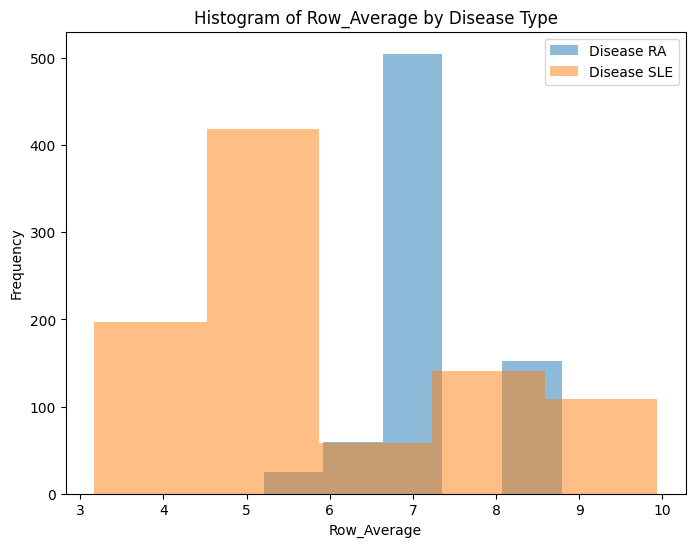

In [18]:
# # Plot a single histogram with both Row_Average and column 'B'
# plt.figure(figsize=(8, 6))

# plt.hist(df['row_average'], bins=5, color='blue', alpha=0.5, label='Row_Average')
# plt.hist(df['numeric_label'], bins=5, color='green', alpha=0.5, label='Disease Type')

# plt.title('Histogram of Row_Average and disease type')
# plt.xlabel('Value')
# plt.ylabel('Frequency')
# plt.legend()

# # Show the plot
# plt.show()


# Plot histograms of Row_Average for each category in 'Category' column
# plt.figure(figsize=(8, 6))

# for category in df['numeric_label'].unique():
#     subset = df[df['numeric_label'] == category]
#     plt.hist(subset['row_average'], bins=5, alpha=0.5, label=f'Disease {category}')

# plt.title('Histogram of Row_Average by Disease Type')
# plt.xlabel('Row_Average')
# plt.ylabel('Frequency')
# plt.legend()

# # Show the plot
# plt.show()

# T-SNE

In [41]:
tcga_final.iloc[:, :-1].head()

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-OR-A5J1,-0.939340,-0.466352,0.401029,1.266991,0.215153,0.161398,-0.441593,-0.316532,-0.199293,3.198534,...,-0.770084,-1.176215,-1.043047,0.216678,0.261435,-0.882198,-0.210720,-1.055239,0.292204,-0.074923
TCGA-OR-A5J2,-1.145131,-0.466352,-0.147640,1.591256,0.101267,-0.648289,-0.475961,-0.316532,-0.199293,1.874709,...,-0.380751,-0.148449,0.396443,-0.380363,2.675816,0.202987,0.842670,-0.335346,1.087713,0.394065
TCGA-OR-A5J3,-0.934030,-0.466352,-0.046539,0.460519,-0.266250,-0.622250,-1.310291,-0.116069,-0.199293,1.017721,...,-1.954676,-1.123239,-0.418684,0.476614,-0.605788,-0.882198,-0.191712,-0.789047,0.366754,-1.209291
TCGA-OR-A5J5,2.028268,-0.420620,-0.120503,-0.660526,-0.978283,0.051628,-0.014454,-0.316532,-0.199293,3.571406,...,-0.513572,0.452585,-1.414351,-1.096205,-0.559996,-0.402566,-0.877807,-0.907348,-0.053325,-0.767609
TCGA-OR-A5J6,1.162276,-0.466352,-0.233298,1.290683,-0.060870,-0.623276,1.145608,-0.316532,-0.199293,0.736984,...,-2.395339,-2.153877,-1.814637,-2.250071,-0.762750,-0.578063,-0.305601,-3.079118,-0.908568,-1.117794


In [50]:
# Step 1: Preprocessing (e.g., log transformation and normalization)
tcga_for_tsne = tcga_final.iloc[:, :-1]
# gene_expression_log = np.log1p(df_tsne)

In [51]:
tcga_for_tsne.columns

Index(['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT',
       'AAA1', 'AAAS',
       ...
       'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
       'ZZEF1', 'ZZZ3'],
      dtype='object', length=20253)

In [83]:
tcga_final.shape

(10223, 20254)

In [52]:
# Step 2: Apply T-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(tcga_for_tsne)

        T-SNE on Full TCGA (10223, 20253) takes around 45.9 s

In [53]:
# Step 3: Create a DataFrame with the T-SNE results
tcga_for_tsne['TSNE-1'] = tsne_results[:,0]
tcga_for_tsne['TSNE-2'] = tsne_results[:,1]

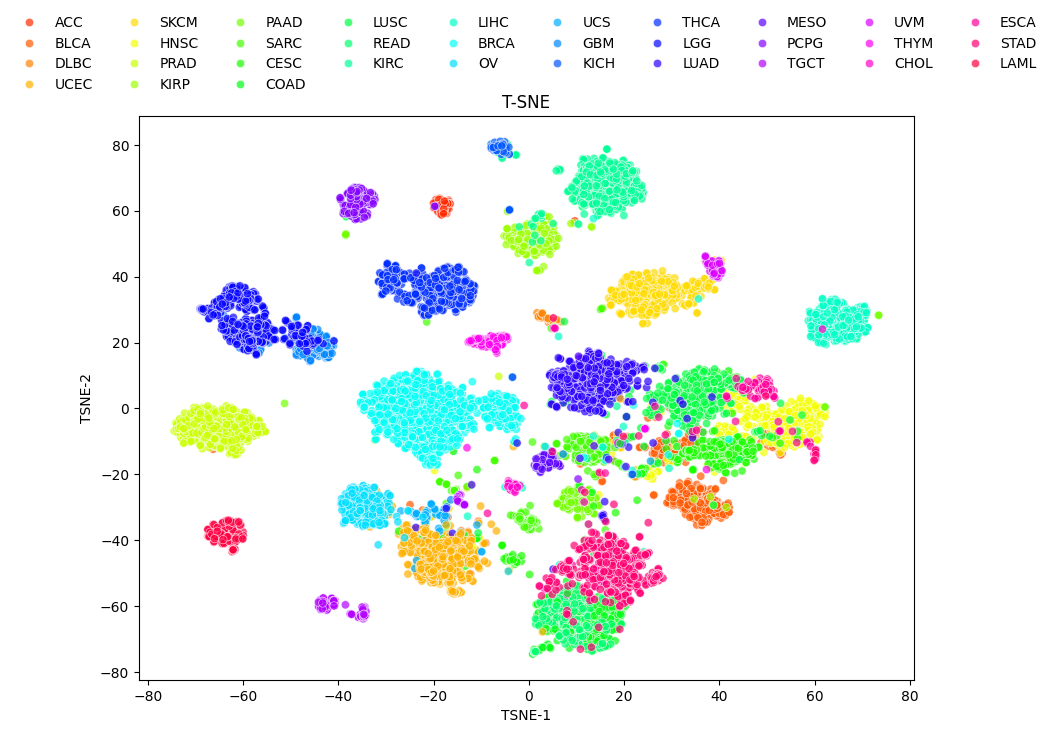

In [76]:
# Step 4: Plot the T-SNE results
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='TSNE-1', y='TSNE-2',
    hue=tcga_final['type'], 
    palette=sns.color_palette("hsv", len(tcga_final['type'].unique())),
    # title="T-SNE results",
    data=tcga_for_tsne,
    legend="full",
    alpha=0.7
)
# Place the legend horizontally at the top of the plot
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=10, frameon=False)

# Adjust the subplot parameters to give more space to the legend
plt.subplots_adjust(top=1.05)


plt.title("T-SNE")
plt.show()

In [147]:
try:
    del tcga_for_tsne
    del tsne_results
except:
    pass

# UMAP

In [78]:
df_umap = tcga_final.iloc[:, :-1]
# gene_expression_log = np.log1p(df_umap)

In [79]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_results = reducer.fit_transform(df_umap)

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [80]:
df_umap['UMAP-1'] = umap_results[:, 0]
df_umap['UMAP-2'] = umap_results[:, 1]

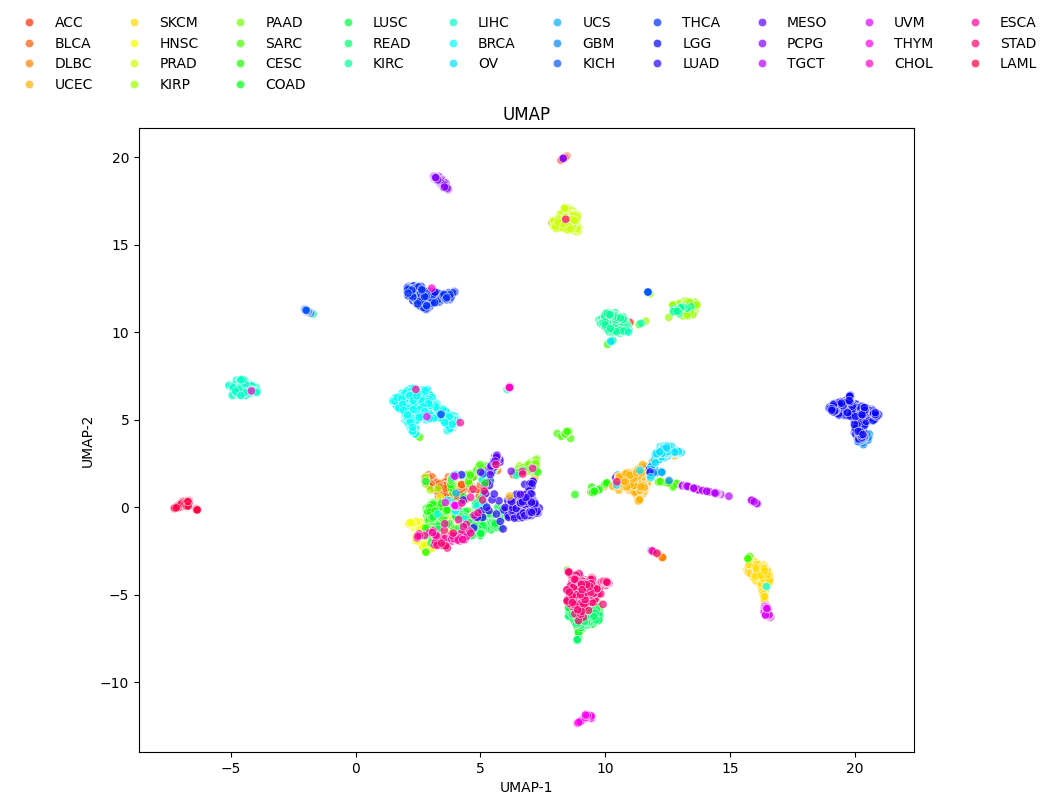

In [87]:
# Step 4: Plot the UMAP results
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='UMAP-1', y='UMAP-2',
    hue=tcga_final['type'],  # Replace with your label column
    palette=sns.color_palette("hsv", len(tcga_final['type'].unique())),
    data=df_umap,
    legend="full",
    alpha=0.7
)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=10, frameon=False)
plt.subplots_adjust(top=1.15)

plt.title("UMAP")
plt.show()

In [88]:
del df_umap, umap_results

# Clustering

In [41]:
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.iloc[:, :-1])

In [42]:
# Initialize KMeans with 2 or 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model to the scaled data
kmeans.fit(df_scaled)

# Assign clusters to the data
df['Cluster'] = kmeans.labels_

In [43]:
df['Cluster']

GSM1101155    2
GSM1101156    2
GSM1101157    2
GSM1101158    2
GSM1101159    2
             ..
GSM1381624    2
GSM1381629    2
GSM1381632    2
GSM1381634    2
GSM1381635    2
Name: Cluster, Length: 1665, dtype: int32

Cluster
2    888
0    514
1    263
Name: count, dtype: int64


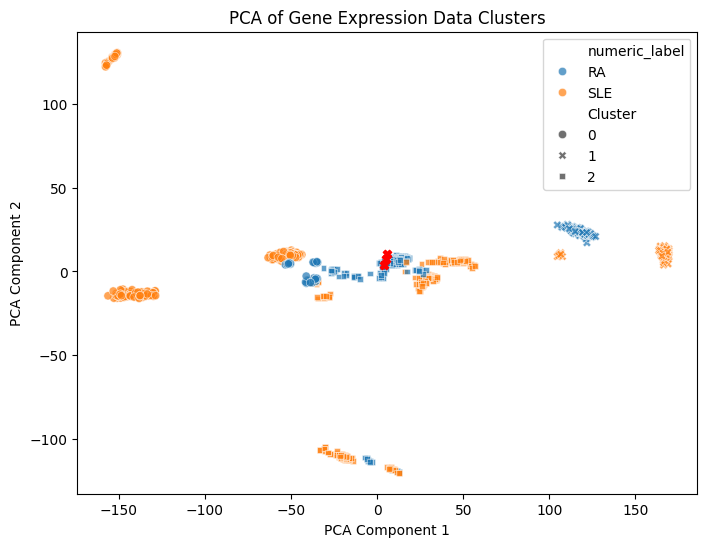

In [44]:
# Count the number of samples in each cluster
print(df['Cluster'].value_counts())

# Optionally, visualize the clusters using PCA (or t-SNE)
from sklearn.decomposition import PCA

# Reduce the dimensionality to 2D for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Create a scatter plot of the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['numeric_label'],  style=df['Cluster'], alpha=0.7)

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centers[:, 0], centers[:, 1],  c='red', marker='X',  label='Centroids')


plt.title('PCA of Gene Expression Data Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [48]:
# Create a cross-tabulation of Clusters vs. Labels
cluster_label_crosstab = pd.crosstab(df['Cluster'], df['numeric_label'])

print(cluster_label_crosstab)

numeric_label   RA  SLE
Cluster                
0               25  489
1              152  111
2              564  324


In [ ]:
df_cluster_0 = df[df['Cluster']==0]
df_cluster_0.drop(['Cluster'], axis=1, inplace=True)

df_cluster_1 = df[df['Cluster']==1]
df_cluster_1.drop(['Cluster'], axis=1, inplace=True)

# df_cluster_2 = df[df['Cluster']==2]
# df_cluster_2.drop(['Cluster'], axis=1, inplace=True)

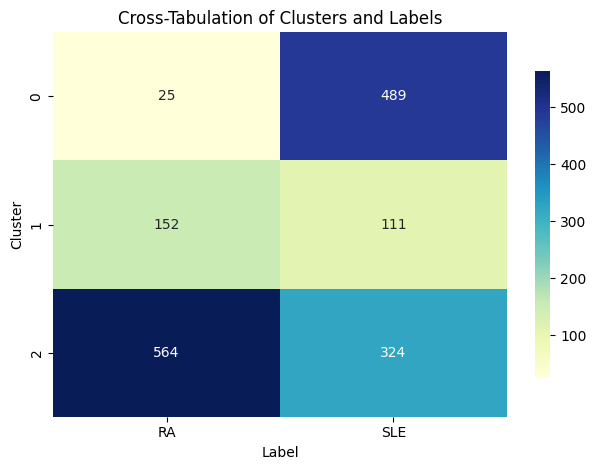

In [46]:
# Optionally, you can visualize this as a heatmap
import seaborn as sns
# plt.figure(figsize=(8, 6))
sns.heatmap(cluster_label_crosstab, annot=True, cmap="YlGnBu", fmt="d", annot_kws={"size": 10}, cbar_kws={'shrink': 0.8})
plt.title('Cross-Tabulation of Clusters and Labels')
plt.xlabel('Label')
plt.ylabel('Cluster')
plt.tight_layout()  # Adjust layout
plt.show()

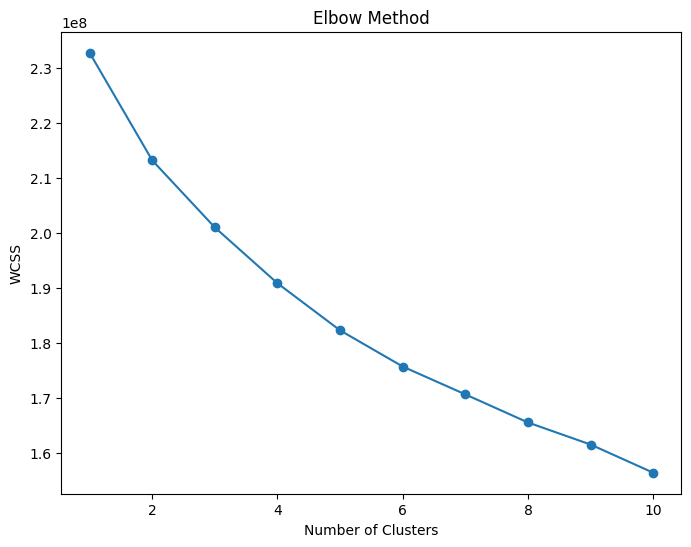

In [281]:
# df_scaled is scaled data
wcss = []
range_n_clusters = range(1, 11)

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tcga_cleaned)
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS

# Plotting the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

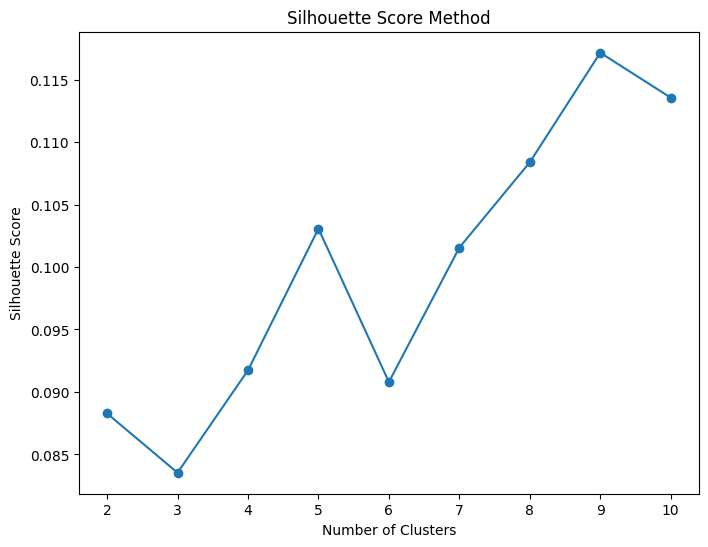

In [282]:
from sklearn.metrics import silhouette_score

range_n_clusters = range(2, 11)
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tcga_cleaned)
    silhouette_avg = silhouette_score(tcga_cleaned, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting the Silhouette Score graph
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

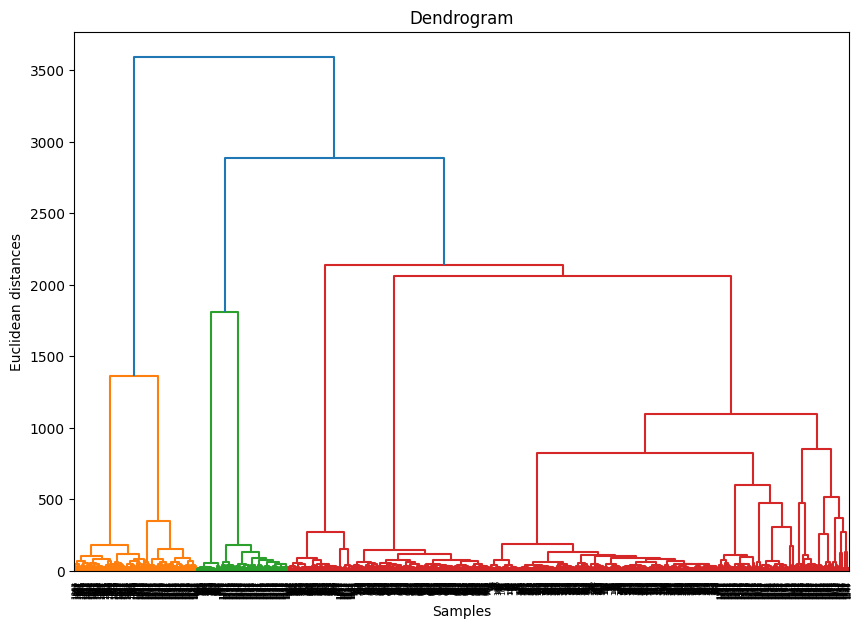

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate the linkage matrix
linked = linkage(df_scaled, 'ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
plt.show()

# Define Model

In [326]:
def check_model_stmfr(df, name_df, target, debug=False):
    ''' 
        Parameters:
                df (pandas DataFrame): A dataframe containing features and a target (in the last column)
                name_df (str): The name of the dataframe passed to this function
                debug (bool): Whether to print debug information

        Returns:
                avg_acc (float): Average accuracy for the 5-fold cross-validation

    '''    
    x = df.iloc[:, :-1]
    # y = df['numeric_label']
    y = df[target]  # For TCGA dataframe

    # scaler = StandardScaler()

    # x_rescaled = pd.DataFrame(scaler.fit_transform(x), index=x.index, columns=x.columns)

    acc_list = []
    b_acc_list = []
    f1_list = []
    prec_list = []
    rec_list = []

    coeff_list = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for train_index, test_index in skf.split(x, y):
        
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # bst = XGBClassifier(n_estimators=2, max_depth=20, learning_rate=1, num_class=4, objective='multi:softmax')
        
        # model = get_model(model_name)
        
        # model = DecisionTreeClassifier(min_samples_split=16, min_samples_leaf=3, max_depth= 15, criterion= 'entropy')
        # model = XGBClassifier(num_class=4, objective='multi:softmax')  #, max_depth=4, learning_rate=0.117, subsample=0.82)

        # model = LogisticRegression(n_jobs=-1, max_iter=250)
        
        # pca = PCA(n_components=0.99)
        # X_train_pca = pca.fit_transform(X_train)
        # X_test_pca = pca.transform(X_test)
        if debug:
            print("\n\n******** Train ************\n\n")
            print(X_train.shape, y_train.shape)
            print("\n\n********* Test ***********\n\n")
            print(X_test.shape, y_test.shape)
            print("\n\n**************************\n\n")
        # fit model
    
        model.fit(X_train, y_train)
        # make predictions
        predictions = model.predict(X_test)

        # print(model.coef_, model.intercept_)
        # coefs_per_fold = pd.DataFrame(zip(X_train.columns, np.transpose(model.coef_)), columns=['features', 'coef']) 
        
        # coeff_list.append(coefs_per_fold)

        # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
        # dtrain.save_binary('train.buffer')

        # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
        # param['nthread'] = 4
        # param['eval_metric'] = 'auc'
        # param['num_class'] = 4

        # num_round = 10
        # bst = xgb.train(param, dtrain, num_round)

        # dtest = xgb.DMatrix(X_test_pca)
        # predictions = bst.predict(dtest)

        # target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
        # target_names = ["SLE", "RA"]
        # print(classification_report(y_test, predictions, target_names=target_names))
        # print(classification_report(y_test, predictions))
        # logger.info(classification_report(y_test, predictions))
        # model_acc = accuracy_score(y_test, predictions, normalize=True)
        # model_acc

        accuracy = accuracy_score(y_test, predictions)
        acc_list.append(accuracy)

        b_accuracy = balanced_accuracy_score(y_test, predictions)
        b_acc_list.append(b_accuracy)

        f1score = f1_score(y_test, predictions, average='weighted')
        f1_list.append(f1score)

        precision = precision_score(y_test, predictions, average='weighted')
        prec_list.append(precision)

        recall = recall_score(y_test, predictions, average='weighted')
        rec_list.append(recall)

        if debug:
            print(accuracy, end='\t')
            print(b_accuracy, end='\t')
            print(f1score, end='\t')
            print(precision, end='\t')
            print(recall)

        # break

    avg_acc = np.average(acc_list)
    print(f"Average for 5-fold cross-validation: {avg_acc} for {name_df}")

    # logger.info("Accuracy of model %s on %s dataset is %f",model_name, name_df, avg_acc)

    if debug:
        print("Accuracy: ", avg_acc, end='\t')
        print("Balanced Accuracy: ", np.average(b_acc_list), end='\t')
        print("F1 score: ", np.average(f1_list), end='\t')
        print("Precision: ", np.average(prec_list), end='\t')
        print("Recall: ", np.average(rec_list))
        # xgb.plot_importance(bst)
        # xgb.plot_tree(bst, num_trees=2)
        # xgb.to_graphviz(bst, num_trees=2)
    return avg_acc #coeff_list

In [ ]:
tcga_final.shape

# Check accuracy on the entire feature set

In [178]:
acc_full_feature = check_model_stmfr(tcga_final, base_dataset)

Average for 5-fold cross-validation:  0.9198868415638353


        RF on TCGA with full feature set takes around 45.7 s

In [23]:
round(acc_full_feature, 3)

0.92

In [ ]:
# debug=0

# check_model_stmfr(tcga, base_dataset)

In [123]:
def check_model_comb_base_derived(base_df, derived_df):

    X_train = base_df.iloc[:, :-1]
    y_train = base_df['numeric_label']

    X_test = derived_df.iloc[:, :-1]
    y_test = derived_df['numeric_label']

    # model = LogisticRegression(n_jobs=-1, max_iter=250)
    # model = get_model(model_name)
    # fit model
    model.fit(X_train, y_train)
    # make predictions
    predictions = model.predict(X_test)

    # target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
    # print(classification_report(y_test, predictions, target_names=target_names))

    # cf_matrix = confusion_matrix(y_test, predictions)

    # cm_display = ConfusionMatrixDisplay(confusion_matrix = cf_matrix, display_labels = ["RA", "SLE"])

    # cm_display.plot()
    # plt.show()
    
    # print(classification_report(y_test, predictions))

    accuracy = accuracy_score(y_test, predictions)
    # acc_list.append(accuracy)

    b_accuracy = balanced_accuracy_score(y_test, predictions)
    # b_acc_list.append(b_accuracy)

    f1score = f1_score(y_test, predictions, average='weighted')
    # f1_list.append(f1score)

    precision = precision_score(y_test, predictions, average='weighted')
    # prec_list.append(precision)

    recall = recall_score(y_test, predictions, average='weighted')
    # rec_list.append(recall)

    # logger.info("Accuracy: %f", accuracy)
    
    print("Accuracy: ", f"{accuracy:.2f}", end='\t')
    print("Balanced Accuracy: ", f"{b_accuracy:.2f}", end='\t')
    print("F1 score: ", f"{f1score:.2f}", end='\t')
    print("Precision: ", f"{precision:.2f}", end='\t')
    print("Recall: ", f"{recall:.2f}")

    return accuracy


In [ ]:
# check_model_comb_base_derived(tcga, df)

# Check accuracy on a cluster (as found by PCA+K-means)

In [68]:
# check_model_stmfr(df, base_dataset)

# check_model_stmfr(df_cluster_1, base_dataset)


Average for 5-fold cross-validation:  1.0


1.0

# Select a number of features randomly 

In [51]:
try:
    orig_df = orig_df.set_index('Unnamed: 0')
    orig_df = orig_df.rename_axis(index=None)
except:
    pass

In [440]:
def random_features_model_accuracy(orig_df, target, remove_cols=True ,batch_size=20, stop_at=10):
    '''
        Parameters:
                orig_df (pandas DataFrame): Original unmodified dataframe containing features and a target (in the last column)
                batch_size (int): how many features to be selected randomly for each round

        Returns:
                batch_numbers (list): A list of batch numbers
                accuracy_values (list): A list of accuracy values corresponding to the batch number in above list
    '''
    # Initialize list to store accuracy values
    accuracy_values = []
    batch_numbers = []

    # Define batch size
    # batch_size = 20

    # Initialize batch counter
    batch_number = 1

    # y = orig_df['numeric_label']
    y = orig_df[target]


    df_rand_feat = orig_df.iloc[:, :-1]

    # Loop until all columns are exhausted
    while len(df_rand_feat.columns) >= batch_size:
        # Randomly select 20 columns
        selected_columns = np.random.choice(df_rand_feat.columns, size=batch_size, replace=False)
        
        # Extract the selected features
        X_batch = df_rand_feat[selected_columns]
        
        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X_batch, y, test_size=0.2, random_state=42)
        
        # Train a model (e.g., Random Forest)
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)
        
        # Predict on the test set and calculate accuracy
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Store the accuracy value
        accuracy_values.append(accuracy)
        batch_numbers.append(batch_number)

        print(f"Batch {batch_number} - Accuracy: {accuracy:.4f}")
        
        # Remove the selected columns from the DataFrame
        if remove_cols:
            df_rand_feat = df_rand_feat.drop(columns=selected_columns)
        
        # Increment the batch counter
        batch_number += 1

        if batch_number > stop_at:
            break 
    
    return batch_numbers, accuracy_values


In [ ]:
tcga_final.type.value_counts()

In [ ]:
tcga_final = pd.read_parquet("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/TCGA/tcga_final.parquet")


In [175]:
label_encoder = LabelEncoder()
tcga_final['type'] = label_encoder.fit_transform(tcga_final.type)

In [181]:
# Runtim: 2m 25s for Autoimmune disease dataset: number of samples : 1665, number of features: 12663, Target: binary classification

stop_at = 100
batches = [100] #[20, 40, 100]

for batch in batches:
    match batch:
        case 15:
            print("\n For batch size 15:")
            batch_numbers, accuracy_random_15 = random_features_model_accuracy(tcga_final, batch_size=batch, stop_at=stop_at)
        case 20:
            print("\n For batch size 20:")
            batch_numbers, accuracy_random_20 = random_features_model_accuracy(tcga_final, batch_size=batch, stop_at=stop_at)
        case 40:
            print("\n For batch size 40:")
            batch_numbers, accuracy_random_40 = random_features_model_accuracy(tcga_final, batch_size=batch, stop_at=stop_at)
        case 100:
            print("\n For batch size 100:")
            batch_numbers, accuracy_random_100 = random_features_model_accuracy(tcga_final, batch_size=batch, stop_at=stop_at)    


 For batch size 100:
Batch 1 - Accuracy: 0.8963
Batch 2 - Accuracy: 0.9061
Batch 3 - Accuracy: 0.8748
Batch 4 - Accuracy: 0.8885
Batch 5 - Accuracy: 0.8890
Batch 6 - Accuracy: 0.9037
Batch 7 - Accuracy: 0.9027
Batch 8 - Accuracy: 0.8890
Batch 9 - Accuracy: 0.8817
Batch 10 - Accuracy: 0.9032
Batch 11 - Accuracy: 0.8905
Batch 12 - Accuracy: 0.8812
Batch 13 - Accuracy: 0.8978
Batch 14 - Accuracy: 0.8856
Batch 15 - Accuracy: 0.9002
Batch 16 - Accuracy: 0.8866
Batch 17 - Accuracy: 0.8719
Batch 18 - Accuracy: 0.9012
Batch 19 - Accuracy: 0.8880
Batch 20 - Accuracy: 0.8905
Batch 21 - Accuracy: 0.8914
Batch 22 - Accuracy: 0.8866
Batch 23 - Accuracy: 0.8846
Batch 24 - Accuracy: 0.9002
Batch 25 - Accuracy: 0.8934
Batch 26 - Accuracy: 0.8914
Batch 27 - Accuracy: 0.8841
Batch 28 - Accuracy: 0.9002
Batch 29 - Accuracy: 0.8929
Batch 30 - Accuracy: 0.8870
Batch 31 - Accuracy: 0.9046
Batch 32 - Accuracy: 0.8822
Batch 33 - Accuracy: 0.8924
Batch 34 - Accuracy: 0.8846
Batch 35 - Accuracy: 0.8880
Batch 3

In [185]:
tcga_final.shape

(10223, 20254)

In [184]:
round(np.mean(accuracy_random_100),2), round(np.std(accuracy_random_100),2)

(0.89, 0.01)

|Batch	|20 random features	| 40 random features | 100 random features |
|-------|------------------|--------------------|--------------------|
|Time(in sec) for 20 batches|53.2|74.4|146|
|1	| 0.7589|    0.8650| 0.9105 | 
|2	| 0.7447|	 0.8313| 0.8817 |
|3	| 0.7271|	 0.8557| 0.8998 |
|4	| 0.6880|	 0.8626| 0.8856 |
|5	| 0.7457|	 0.8381| 0.9066 | 
|6	| 0.7120|	 0.8279| 0.8998 |
|7	| 0.7482|	 0.7936| 0.8929 |  
|8	| 0.6890|	 0.8352| 0.8949 |
|9	| 0.7628|	 0.8333| 0.8929 |

In [106]:
# tcga_final.type.value_counts()
tcga_final.shape[1]

20254

# Plot accuracy for various random features selected

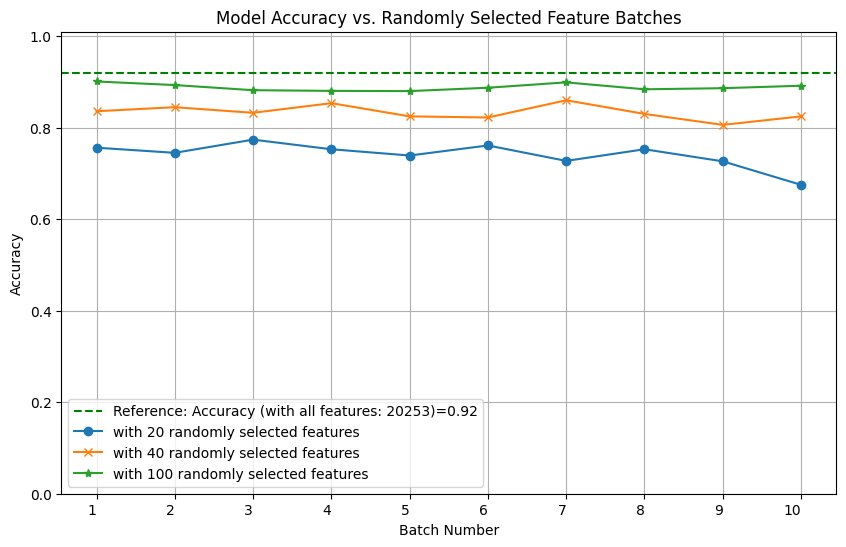

In [24]:
# Plot the accuracy values
plt.figure(figsize=(10, 6))

# Add a reference line
reference_value = round(acc_full_feature,3)
plt.axhline(y=reference_value, color='g', linestyle='--', label=f'Reference: Accuracy (with all features: {tcga_final.shape[1]-1})={reference_value}')

plt.plot(batch_numbers, accuracy_random_20, marker='o', linestyle='-',  label="with 20 randomly selected features")
plt.plot(batch_numbers, accuracy_random_40, marker='x', linestyle='-',  label="with 40 randomly selected features")
plt.plot(batch_numbers, accuracy_random_100, marker='*', label="with 100 randomly selected features")

plt.title("Model Accuracy vs. Randomly Selected Feature Batches")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim([0, 1.01])
# plt.yticks((np.arange(0, 1, step=0.2)))
plt.grid(True)

plt.xticks(range(1, len(batch_numbers) + 1, 1), rotation=0, ha="right")

plt.legend()
plt.show()

# Test code

In [ ]:
# 2, 5, 10, 12, 50, 100, 500, 1000, original_set = orig_df.shape[1]

num_features = orig_df.shape[1]

acc_list = []
coeffs_list = []
debug=0

start = timer()

for i in tqdm(range(20)):
    df = orig_df
    # df = df.sample(frac=0.1,axis='columns')
    # df = df.sample(frac=0.001,axis='columns')

    df = df.sample(n=num_features,axis='columns')
    # df.shape

    df['numeric_label'] = orig_df['numeric_label']

    df.insert(len(df.columns)-1, 'numeric_label', df.pop('numeric_label'))

    print(df.shape)
    acc, coeffs = check_model_stmfr(df, base_dataset)
    acc_list.append(acc)
    coeffs_list.append(coeffs)

end = timer()

print("for features=", num_features, ", Mean accuracy : %.4f" %np.mean(acc_list), ", StdDev : %.4f" %np.std(acc_list), "(Averaged for 20 runs: Timer per run: %.2f)"  %((end-start)/20))

Model LR on Set A (5-fold cross validation):

    for features= 2 , Mean accuracy : 0.6626 , StdDev : 0.0996 (Averaged for 20 runs: Timer per run: 0.20)

    for features= 5 , Mean accuracy : 0.7857 , StdDev : 0.0714 (Averaged for 20 runs: Timer per run: 0.25)

    for features= 10 , Mean accuracy : 0.9041 , StdDev : 0.0545 (Averaged for 20 runs: Timer per run: 0.10)

    for features= 12 , Mean accuracy : 0.9370 , StdDev : 0.0257 (Averaged for 20 runs: Timer per run: 0.10)

    for features= 50 , Mean accuracy : 0.9919 , StdDev : 0.0036 (Averaged for 20 runs: Timer per run: 0.18)

    for features= 100 , Mean accuracy : 0.9982 , StdDev : 0.0011 (Averaged for 20 runs: Timer per run: 2.98)

    for features= 500 , Mean accuracy : 0.9999 , StdDev : 0.0002 (Averaged for 20 runs: Timer per run: 3.14)

    for features= 1000 , Mean accuracy : 0.9998 , StdDev : 0.0003 (Averaged for 20 runs: Timer per run: 3.43)

    for features= 12264 , Mean accuracy : 1.0000 , StdDev : 0.0000 (Averaged for 20 runs: Timer per run: 11.48)


# Feature selection using Random Forest

In [80]:
X_train = tcga_final.iloc[:, :-1]
y_train = tcga_final['type']

# Assuming X_train is the feature matrix and y_train is the target vector
rf_feature_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_feature_model.fit(X_train, y_train)

# Get feature importance scores
rf_importances = rf_feature_model.feature_importances_

# Rank features by importance
rf_feature_indices = np.argsort(rf_importances)[::-1]

RF on TCGA dataset took 2m 32.8s for feature importance 

In [ ]:
# # Print top 10 features
# for i in range(10):
#     print(f"Gene {rf_feature_indices[i]}: Importance Score = {rf_importances[rf_feature_indices[i]]}")

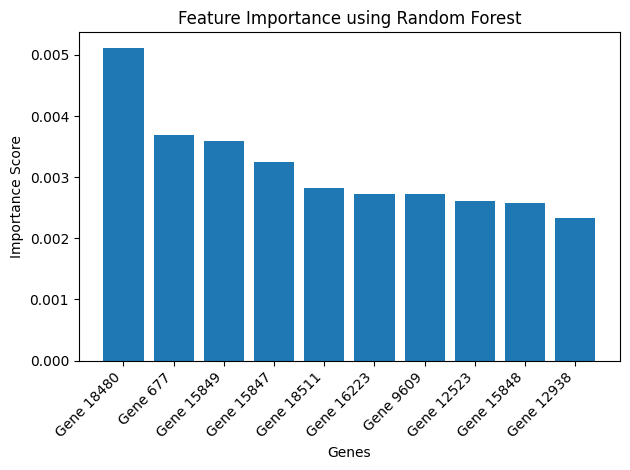

In [81]:
# Plot the top 10 important features
# plt.figure(figsize=(10, 6))
plt.title("Feature Importance using Random Forest")
plt.bar(range(10), rf_importances[rf_feature_indices[:10]], align='center')
plt.xticks(range(10), [f'Gene {i}' for i in rf_feature_indices[:10]], rotation=45, ha="right")


plt.xlabel("Genes")
plt.ylabel("Importance Score")
plt.tight_layout()  # Adjusts plot to ensure labels fit into the figure area
plt.show()

In [82]:
del X_train, y_train

# Select top n features(via RF/GB) and train RF

In [114]:
pd.options.mode.chained_assignment = None  # default='warn'

In [78]:
def cal_acc_selected_features(df, sorted_features_indices, batch_size = 20, stop_at=20):
    # batch_size = 20
    feature_selection_acc = []
    
    for i in range(0, len(sorted_features_indices), batch_size): # rf_feature_indices # len(gb_feature_indices)
        top_20_features_indices = sorted_features_indices[i:i+batch_size]

        top_20_features = df.columns[top_20_features_indices]

        top_20_df = df[top_20_features]

        # top_20_df['numeric_label'] = df['numeric_label']
        top_20_df['type'] = df['type']
        top_20_df.insert(len(top_20_df.columns)-1, 'type', top_20_df.pop('type'))

        # top_20_df.insert(len(top_20_df.columns)-1, 'numeric_label', top_20_df.pop('numeric_label'))

        # print("\n\n****************************************************************")
        # print(f"Batch {i // batch_size + 1}:")
        # print(top_20_features)

        # print(top_20_df.shape)
        acc = check_model_stmfr(top_20_df, base_dataset)
        
        feature_selection_acc.append(acc)

        print(f"Batch {i/batch_size} - Accuracy: {acc:.4f}")

        if i >= batch_size*(stop_at-1):
            break

    return feature_selection_acc

In [199]:
rf_feature_selection_acc = cal_acc_selected_features(tcga_final, rf_feature_indices, batch_size=40, stop_at=10)

/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_51096/2696262624.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_df['type'] = df['type']
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_51096/2696262624.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

Average for 5-fold cross-validation:  0.8923989109995741
Batch 0.0 - Accuracy: 0.8924
Average for 5-fold cross-validation:  0.892301781348236
Batch 1.0 - Accuracy: 0.8923


/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_51096/2696262624.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_df['type'] = df['type']


Average for 5-fold cross-validation:  0.8995406676586969
Batch 2.0 - Accuracy: 0.8995


/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_51096/2696262624.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_df['type'] = df['type']


...

Average for 5-fold cross-validation:  0.8745961942401637
Batch 7.0 - Accuracy: 0.8746


/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_51096/2696262624.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_df['type'] = df['type']
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Average for 5-fold cross-validation:  0.8719545069593636
Batch 8.0 - Accuracy: 0.8720


/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_51096/2696262624.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_df['type'] = df['type']


Average for 5-fold cross-validation:  0.8741081536275294
Batch 9.0 - Accuracy: 0.8741


In [84]:
rf_feature_selection_acc

[0.7677776448691143,
 0.8134603514849352,
 0.7536923621644123,
 0.7570191723405376,
 0.7737445633711165,
 0.8314586672663505,
 0.7979059708419658,
 0.7579964018966598,
 0.7974179780764502,
 0.7441052828003961]

# Add result for top-n features selected by RF to the plot

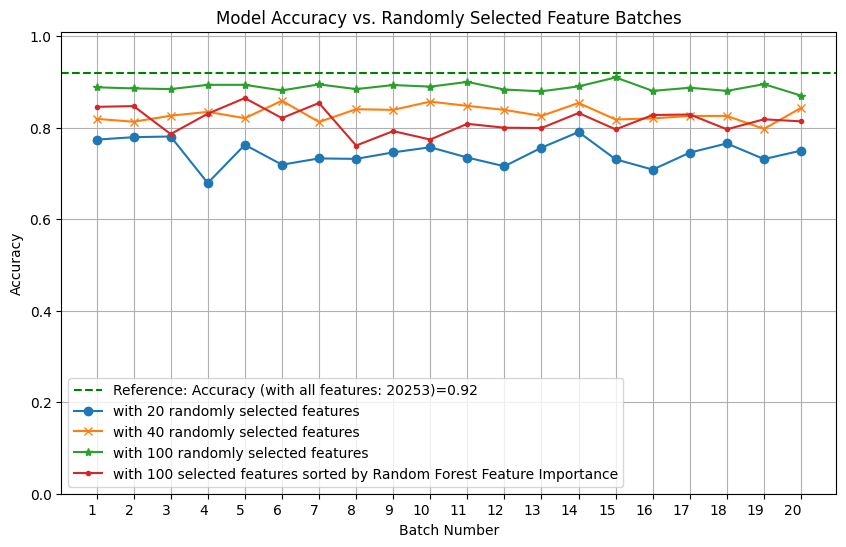

In [142]:
# # Plot the accuracy values
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, len(rf_feature_selection_acc) + 1), rf_feature_selection_acc, marker='o', linestyle='-', color='b')
# plt.ylim([0, 1.01])
# plt.title("Model Accuracy vs. Feature Batches(20): Gradient Boosting")
# plt.xlabel("Batch Number")
# plt.ylabel("Accuracy")
# plt.grid(True)
# plt.xticks(range(1, len(rf_feature_selection_acc) + 1, 1), rotation=0, ha="right")
# plt.show()

# Plot the accuracy values
plt.figure(figsize=(10, 6))

# Add a reference line
reference_value = 0.92
plt.axhline(y=reference_value, color='g', linestyle='--', label=f'Reference: Accuracy (with all features: {tcga_final.shape[1]-1})={reference_value}')

plt.plot(batch_numbers, accuracy_random_20, marker='o', linestyle='-',  label="with 20 randomly selected features")
plt.plot(batch_numbers, accuracy_random_40, marker='x', linestyle='-',  label="with 40 randomly selected features")
plt.plot(batch_numbers, accuracy_random_100, marker='*', label="with 100 randomly selected features")
plt.plot(batch_numbers, rf_feature_selection_acc, marker='.', label="with 100 selected features sorted by Random Forest Feature Importance")

plt.title("Model Accuracy vs. Randomly Selected Feature Batches")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim([0, 1.01])
# plt.yticks((np.arange(0, 1, step=0.2)))
plt.grid(True)

plt.xticks(range(1, len(batch_numbers) + 1, 1), rotation=0, ha="right")

plt.legend()
plt.show()

# Feature selection using Gradient Boosting

In [364]:
X_train = tcga_final.iloc[:, :-1]
y_train = tcga_final['type']

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# GradientBoostingClassifier(n_estimators=500, validation_fraction=0.1, n_iter_no_change=10)

gb_model.fit(X_train, y_train)

In [ ]:
# Get feature importance scores
gb_feature_importances = model.feature_importances_

# Rank features by importance
gb_feature_indices = np.argsort(gb_feature_importances)[::-1]

# Print top 10 features
for i in range(10):
    print(f"Gene {gb_feature_indices[i]}: Importance Score = {gb_feature_importances[gb_feature_indices[i]]}")

Gene 8529: Importance Score = 0.741383032872039
Gene 9454: Importance Score = 0.06097720199163048
Gene 3022: Importance Score = 0.038620833347169
Gene 3440: Importance Score = 0.028901290631918923
Gene 5907: Importance Score = 0.028741847922405653
Gene 7598: Importance Score = 0.025940778057405606
Gene 8877: Importance Score = 0.019599199931583298
Gene 8647: Importance Score = 0.012663078244531797
Gene 11515: Importance Score = 0.011286504648839766
Gene 7633: Importance Score = 0.005379816056555537


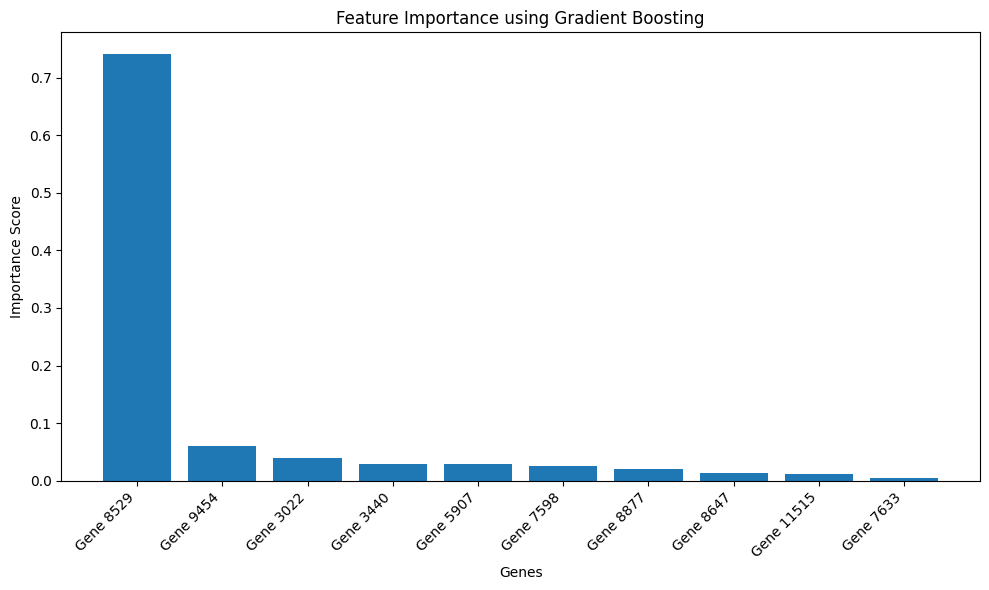

In [ ]:
# Plot the top 10 important features
plt.figure(figsize=(10, 6))
plt.title("Feature Importance using Gradient Boosting")
plt.bar(range(10), gb_feature_importances[gb_feature_indices[:10]], align='center')
plt.xticks(range(10), [f'Gene {i}' for i in gb_feature_indices[:10]], rotation=45, ha="right")  # Rotate x-axis labels

plt.xlabel("Genes")
plt.ylabel("Importance Score")
plt.tight_layout()  # Adjusts plot to ensure labels fit into the figure area
plt.show()

In [ ]:
gb_feature_indices

array([8529, 9454, 3022, ..., 8156, 8155,  215])

# Genetic Algorithm based Feature Importance

# Test code

In [127]:
orig_df

,MAFIP,ACP2,DOHH,SNORA70,TNK2,GOLGA6L9,SCD,ACSL5,C12orf29,VAT1,...,RPL13AP3,CTAGE6,SERINC4,RPL23AP87,ALMS1P1,RPL31P11,IGKV3-20,CTCFL,FAM41C,numeric_label
GSM1101155,7.177125,7.034467,6.344134,0.0,5.432413,7.407132,6.748544,8.847534,6.210873,8.009128,...,13.003048,6.551936,6.864552,6.555548,5.258999,13.018441,8.117222,6.042811,7.587628,RA
GSM1101156,6.773349,6.976631,6.525447,0.0,5.734064,7.565163,7.294664,8.663807,6.217797,7.895504,...,12.488611,7.564457,5.634840,8.141043,4.637764,12.905548,6.294197,6.261517,8.017405,RA
GSM1101157,6.059652,6.457220,6.392728,0.0,5.379978,6.373413,5.675553,8.187035,4.955460,7.283289,...,12.673501,6.115201,5.922216,6.929015,4.998197,12.608205,7.140879,7.325408,7.684934,RA
GSM1101158,7.087894,6.798172,5.939988,0.0,4.947094,6.891383,6.504845,8.417203,6.025977,7.837791,...,12.891254,6.617376,6.204495,7.272915,4.773569,12.880149,6.483203,6.212810,7.424610,RA
GSM1101159,7.791554,7.020820,6.387722,0.0,4.838470,7.536355,7.221244,8.851789,6.340770,8.206868,...,12.874432,6.746431,6.186414,7.938200,4.736272,12.896527,7.304036,6.759730,7.672359,RA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1381624,5.743025,7.757006,6.279358,0.0,5.526591,5.642777,6.023694,9.587408,4.863397,8.514796,...,13.536827,7.062605,7.827703,7.110618,4.621579,13.094480,5.770272,9.473206,8.965263,RA
GSM1381629,5.199477,7.758685,6.627402,0.0,5.482310,4.364626,6.965378,9.519423,5.728723,9.275847,...,13.611272,6.621235,8.330889,5.405805,4.022834,12.973511,7.889597,7.889237,8.118608,RA
GSM1381632,4.929325,7.466323,6.036249,0.0,5.550331,5.298057,6.209948,9.492464,5.417386,9.377646,...,13.619753,7.358538,8.219532,7.088301,4.266537,13.101146,5.181912,9.388769,9.046513,RA
GSM1381634,5.409941,6.890426,6.017240,0.0,5.617178,4.795757,7.398027,10.803079,4.785795,8.554422,...,13.490800,6.997367,8.612774,6.061840,4.581865,13.107362,6.466464,9.386339,8.485404,RA


In [128]:
try:
    orig_df = orig_df.set_index('Unnamed: 0')
    orig_df = orig_df.rename_axis(index=None)

    orig_tcga = orig_tcga.set_index('Unnamed: 0')
    orig_tcga = orig_tcga.rename_axis(index=None)
except:
    pass

In [129]:
check_model_comb_base_derived(orig_df, orig_tcga)

Accuracy:  0.85	Balanced Accuracy:  0.59	F1 score:  0.81	Precision:  0.83	Recall:  0.85


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8469241773962805

In [158]:
# 2, 5, 10, 12, 50, 100, 500, 1000, original_set

num_features = orig_df.shape[1]

acc_list = []
coeffs_list = []
debug=0
start = timer()
for i in tqdm(range(20)):
    
    # df = orig_df
    # df = df.sample(frac=0.1,axis='columns')
    # df = df.sample(frac=0.001,axis='columns')

    df = orig_df.sample(n=num_features,axis='columns')
    # df.shape

    df['numeric_label'] = orig_df['numeric_label']

    df.insert(len(df.columns)-1, 'numeric_label', df.pop('numeric_label'))

    cols = df.columns

    tcga = orig_tcga[cols]

    # print(df.shape)
    acc = check_model_comb_base_derived(df, tcga)
    acc_list.append(acc)
    # coeffs_list.append(coeffs)
end = timer()

print("for features=", num_features, ", Mean accuracy : %.4f" %np.mean(acc_list), ", StdDev : %.4f" %np.std(acc_list), "(Averaged for 20 runs: Timer per run: %.2f)"  %((end-start)/20))

  5%|▌         | 1/20 [00:02<00:56,  2.95s/it]

Accuracy:  0.85	Balanced Accuracy:  0.59	F1 score:  0.81	Precision:  0.83	Recall:  0.85


 10%|█         | 2/20 [00:05<00:51,  2.86s/it]

Accuracy:  0.85	Balanced Accuracy:  0.59	F1 score:  0.81	Precision:  0.83	Recall:  0.85


 15%|█▌        | 3/20 [00:08<00:49,  2.90s/it]

...

Accuracy:  0.85	Balanced Accuracy:  0.59	F1 score:  0.81	Precision:  0.83	Recall:  0.85


 95%|█████████▌| 19/20 [00:54<00:02,  2.80s/it]

Accuracy:  0.85	Balanced Accuracy:  0.59	F1 score:  0.81	Precision:  0.83	Recall:  0.85


100%|██████████| 20/20 [00:57<00:00,  2.86s/it]

Accuracy:  0.85	Balanced Accuracy:  0.59	F1 score:  0.81	Precision:  0.83	Recall:  0.85
for features= 12264 , Mean accuracy : 0.8467 , StdDev : 0.0008 (Averaged for 20 runs: Timer per run: 2.86)


Train LR on Set A, predict for Set B:

    for features= 2 , Mean accuracy : 0.6494 , StdDev : 0.2193 (Averaged for 20 runs: Timer per run: 0.02)

    for features= 5 , Mean accuracy : 0.6615 , StdDev : 0.2146 (Averaged for 20 runs: Timer per run: 0.02)

    for features= 10 , Mean accuracy : 0.6486 , StdDev : 0.2299 (Averaged for 20 runs: Timer per run: 0.03)

    for features= 12 , Mean accuracy : 0.6946 , StdDev : 0.1998 (Averaged for 20 runs: Timer per run: 0.03)

    for features= 50 , Mean accuracy : 0.8084 , StdDev : 0.0880 (Averaged for 20 runs: Timer per run: 0.04)

    for features= 100 , Mean accuracy : 0.8406 , StdDev : 0.0393 (Averaged for 20 runs: Timer per run: 0.61)

    for features= 500 , Mean accuracy : 0.8436 , StdDev : 0.0119 (Averaged for 20 runs: Timer per run: 0.66)

    for features= 1000 , Mean accuracy : 0.8460 , StdDev : 0.0034 (Averaged for 20 runs: Timer per run: 0.72)

    for features= 12263 , Mean accuracy : 0.8467 , StdDev : 0.0008 (Averaged for 20 runs: Timer per run: 2.86)


In [150]:
df.shape, tcga.shape

((1665, 3), (699, 3))

In [134]:
df = orig_df.sample(n=num_features,axis='columns')
# df.shape

df['numeric_label'] = orig_df['numeric_label']

df.insert(len(df.columns)-1, 'numeric_label', df.pop('numeric_label'))

cols = df.columns

tcga = orig_tcga[cols]

check_model_comb_base_derived(df, tcga)

Accuracy:  0.29	Balanced Accuracy:  0.43	F1 score:  0.31	Precision:  0.64	Recall:  0.29


0.2861230329041488

In [135]:
tcga

,HES6,DNAH1,numeric_label
GSM2902013,6.015528,7.042874,SLE
GSM2902014,5.676884,7.138630,SLE
GSM2902015,4.657067,7.142303,SLE
GSM2902016,6.004245,7.404789,SLE
GSM2902017,5.898020,7.844959,SLE
...,...,...,...
GSM3559688,6.988114,6.554261,SLE
GSM3559692,7.033675,5.745611,SLE
GSM3559719,6.163942,5.909570,SLE
GSM3559730,6.990302,6.609842,SLE


In [72]:
check_model_stmfr(df, base_dataset)



******** Train ************


(1332, 100) (1332,)


********* Test ***********


(333, 100) (333,)


**************************




/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.996996996996997	0.9966442953020134	0.996996010546146	0.997013229445662	0.996996996996997


******** Train ************


(1332, 100) (1332,)


********* Test ***********


(333, 100) (333,)


**************************




/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.0	1.0	1.0	1.0	1.0


******** Train ************


(1332, 100) (1332,)


********* Test ***********


(333, 100) (333,)


**************************


0.996996996996997	0.9966216216216216	0.9969959543352571	0.9970131421744325	0.996996996996997


******** Train ************


(1332, 100) (1332,)


********* Test ***********


(333, 100) (333,)


**************************


0.996996996996997	0.9966216216216216	0.9969959543352571	0.9970131421744325	0.996996996996997


******** Train ************


(1332, 100) (1332,)


********* Test ***********


(333, 100) (333,)


**************************


1.0	1.0	1.0	1.0	1.0
Average for 5-fold cross-validation:

Accuracy:  0.9981981981981981	Balanced Accuracy:  0.9979775077090511	F1 score:  0.9981975838433321	Precision:  0.9982079027589055	Recall:  0.9981981981981981


(0.9981981981981981,
 [   features                    coef
  0      KAT5   [0.11434423678923261]
  1     UBFD1  [-0.06595022286587736]
  2     UGGT1   [0.17779426099239684]
  3   TMEM105    [-0.566492106539147]
  4    ZNF304   [0.04912930920537645]
  ..      ...                     ...
  95   RNF145    [0.0769577027227715]
  96   CYSTM1   [0.11871811461356299]
  97   STAMBP   [0.09236982095240028]
  98   LYPLA2   [0.01567439585720712]
  99     AATK  [-0.12241138710471662]
  
  [100 rows x 2 columns],
     features                      coef
  0      KAT5     [0.20317156368465986]
  1     UBFD1   [-0.030888631575962937]
  2     UGGT1      [0.1409372507218627]
  3   TMEM105     [-0.5047971376971483]
  4    ZNF304     [0.04672839435099411]
  ..      ...                       ...
  95   RNF145     [0.07715722806163282]
  96   CYSTM1      [0.0693280957109588]
  97   STAMBP     [-0.0833144521189174]
  98   LYPLA2   [-0.053066088252691955]
  99     AATK  [-0.0054493712052638135]
  
  [100 rows

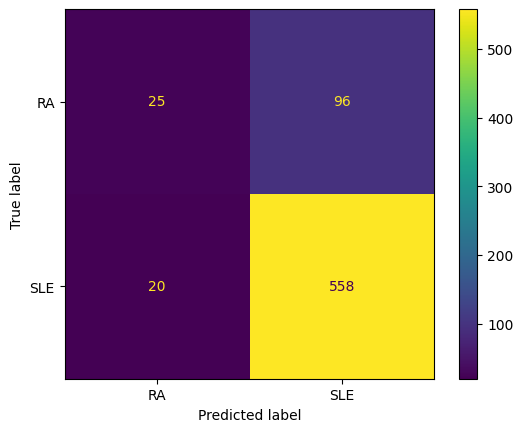

              precision    recall  f1-score   support

          RA       0.56      0.21      0.30       121
         SLE       0.85      0.97      0.91       578

    accuracy                           0.83       699
   macro avg       0.70      0.59      0.60       699
weighted avg       0.80      0.83      0.80       699

Accuracy:  0.83	Balanced Accuracy:  0.59	F1 score:  0.80	Precision:  0.80	Recall:  0.83


0.8340486409155937

In [71]:
check_model_comb_base_derived(df, tcga)

In [334]:
pd.DataFrame(coeffs_list)[0]

0     [[-0.5400509937167793, -1.5877719842172273, 0....
1     [[-0.40306377587455916, 2.9633320794550135, 0....
2     [[-1.466925807176049, 0.04341318263024543, 1.0...
3     [[-0.21964731936404794, 0.513008274515623, 0.1...
4     [[1.506941540076379, -1.5812994796956943, 0.25...
5     [[-0.33808510290202143, 1.1626850689415715, 0....
6     [[-0.29675725809874265, -2.393477817164003, 3....
7     [[2.6686375944623344, -0.561252264727367, -0.9...
8     [[0.7282127528510511, -2.6075855054652233, -0....
9     [[-0.6043492125382285, -1.2204395202005207, 0....
10    [[-0.8320869456109686, 0.4227251639865543, 2.2...
11    [[0.3392595937990869, -0.1319850041271894, -0....
12    [[-0.1916120382742035, -0.6122740873630879, -1...
13    [[-1.453283763156428, 0.02277467681220465, 0.7...
14    [[0.8851526474444896, -0.3506771117472275, -0....
15    [[1.0465805810114586, 0.6516818043631886, -0.7...
16    [[0.4459462312779935, 1.2061372820021723, 0.56...
17    [[1.2450322239996097, -3.016670941158769, 

In [1]:
np.mean(acc_list), np.std(acc_list)

NameError: name 'np' is not defined

In [311]:
label_encoder = LabelEncoder()
df['numeric_label'] = label_encoder.fit_transform(df.numeric_label)

In [312]:
# x = df.iloc[:, :-1]
# y = df['numeric_label']

# df['numeric_label'] = label_encoder.fit_transform(df.numeric_label)

# import statsmodels.api as sm
# logit_model=sm.Logit(y,x)
# result=logit_model.fit()
# print(result.summary())

Optimization terminated successfully.
         Current function value: 0.087468
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:          numeric_label   No. Observations:                 1665
Model:                          Logit   Df Residuals:                     1653
Method:                           MLE   Df Model:                           11
Date:                Thu, 07 Mar 2024   Pseudo R-squ.:                  0.8727
Time:                        20:45:44   Log-Likelihood:                -145.63
converged:                       True   LL-Null:                       -1144.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
TNFSF10        1.2450      0.189      6.583      0.000       0.874       1.616
PSMD4          0.4011      0

In [228]:
# df['numeric_label']

0       RA
1       RA
2       RA
3       RA
4       RA
        ..
1660    RA
1661    RA
1662    RA
1663    RA
1664    RA
Name: numeric_label, Length: 1665, dtype: object

Moves the target column to the end

In [209]:
df

,CTDSP1,CD79A,C2orf69,PHYKPL,CERS5,RAD51,CSTF2T,SRSF8,TRERF1,PCMTD1,PITPNC1,HNRNPA3,numeric_label
0,9.291339,8.264156,8.649292,7.745442,8.904429,5.213228,5.929988,7.726674,7.066741,7.214647,6.070798,9.364143,RA
1,9.251268,6.955627,8.469807,7.663036,9.034863,4.690419,5.839229,7.097250,7.422859,7.731640,6.021829,9.250039,RA
2,9.519798,6.440820,8.726572,8.205181,9.332152,4.789512,5.472563,6.960612,7.343871,9.101953,6.366749,9.094068,RA
3,9.361260,7.144140,8.697802,7.653158,9.032873,4.946637,5.918057,7.286342,7.350470,7.717337,6.454927,9.522570,RA
4,8.968902,7.119311,8.753540,7.692055,8.799807,4.562568,5.974717,7.685553,7.293617,8.261842,6.270154,9.398970,RA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,10.208691,4.969147,10.238246,8.641834,9.671639,4.632611,5.902001,7.802075,5.681833,8.236980,4.973513,10.778395,RA
1661,10.628321,5.647412,9.048425,8.317108,10.191367,4.996033,5.408480,7.523024,6.249255,6.997184,5.557788,10.651168,RA
1662,10.812811,4.611216,10.036437,8.855578,10.015875,5.020000,5.656893,7.331811,5.870914,8.112027,5.796245,10.848051,RA
1663,10.363240,5.211510,10.045071,8.040380,10.401630,4.919378,5.016509,6.136720,4.795381,6.517347,5.108440,11.152160,RA


In [207]:
df.numeric_label.value_counts()

numeric_label
SLE    924
RA     741
Name: count, dtype: int64

# Comparison with Li et al. BMC Genomics (2017)  

In [ ]:
label_encoder = LabelEncoder()
df['numeric_label'] = label_encoder.fit_transform(df.numeric_label)

In [171]:
cols = tcga_final.columns

NameError: name 'tcga_final' is not defined

In [51]:
cols

Index(['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT',
       'AAA1', 'AAAS',
       ...
       'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX', 'ZZEF1',
       'ZZZ3', 'type'],
      dtype='object', length=20254)

In [97]:
freq_20_genes = ['TCF21', 'TBX5', 'EMX2OS', 'EMX2', 'PA2G4P4', 'HNF1B', 'ATP5EP2', 'NACA2', 'PTTG3P', 'FTH1P3', 'SFTPA1', 'HSPB1P1', 'GATA3', 'NAPSA', 'ANXA2P3', 'IGPB1P1', 'HOXA9', 'STFA3', 'RPL19P12', 'SFTPA2']

In [106]:
# top_genes_paper_common_tcga = (list(set(tcga_final.columns) & set(freq_20_genes)))

for col in freq_20_genes:
    if col in cols:
        # print(f"'{col}' exists")
        pass
    else:
        print(f"'{col}' does not exist")

'FTH1P3' does not exist
'HSPB1P1' does not exist
'IGPB1P1' does not exist
'STFA3' does not exist


In [189]:
substring = 'RPL17'

# Find columns that contain the substring
matching_columns = [col for col in tcga_final.columns if substring in col]

print(matching_columns)

['MRPL17', 'RPL17']


Found = ['EMX2', 'EMX2OS', 'HOXA9', 'HOXA11AS', 'TCF21', 'HNF1B', 'GJB1', 'PTTG3P', 'ANXA2P3', 'HSP90B3P', 'TBX5', 'HAND2', 'SOX10', 'SFTPA2', 'SFTPA1', 'SFTPC', 'NAPSA', 'SFTPB', 'SFTA3',
'NKX2-1', 'GATA3', 'IRX5', 'ATP5EP2', 'PA2G4P4', 'RPL19P12', 'ANXA2P1', 'MFSD2B', 'FOXF1', 'FOXA1', 'SLC34A2', 'NACA2', 'RPL23P8', 'TRPS1', 'MEIS1', 'PABPC3', 'TBX3', 'SFN', 'EPCAM', 'CLDN3', 'RPL17']

Not Found = 'SMIM6', 'IGBP1P1', 'GATA3-AS1', 'YBX3P1', 'FTH1P3', 'HSPB1P1', 'UQCRB', 'HNRNPA1P33', 'KRT7', '

Is 'IGBP1P1' == 'IGBP1'
Is 'GATA3-AS1' == 'GATA3'
Is 'HSPB1P1' == 'HSPBP1'
Is 'UQCRBP1 == 'UQCRB'

In [190]:
Found = ['EMX2', 'EMX2OS', 'HOXA9', 'HOXA11AS', 'TCF21', 'HNF1B', 'GJB1', 'PTTG3P', 'ANXA2P3', 'HSP90B3P', 'TBX5', 'HAND2', 'SOX10', 'SFTPA2', 'SFTPA1', 'SFTPC', 'NAPSA', 'SFTPB', 'SFTA3',
'NKX2-1', 'GATA3', 'IRX5', 'ATP5EP2', 'PA2G4P4', 'RPL19P12', 'ANXA2P1', 'MFSD2B', 'FOXF1', 'FOXA1', 'SLC34A2', 'NACA2', 'RPL23P8', 'TRPS1', 'MEIS1', 'PABPC3', 'TBX3', 'SFN', 'EPCAM', 'CLDN3', 'RPL17']

In [191]:
len(Found)

40

In [114]:
sorted(top_genes_paper_common_tcga)

['ANXA2P3',
 'ATP5EP2',
 'EMX2',
 'EMX2OS',
 'GATA3',
 'HNF1B',
 'HOXA9',
 'NACA2',
 'NAPSA',
 'PA2G4P4',
 'PTTG3P',
 'RPL19P12',
 'SFTPA1',
 'SFTPA2',
 'TBX5',
 'TCF21']

In [192]:
df = tcga_final[Found]
df['type'] = tcga_final['type']

/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_51096/265882666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['type'] = tcga_final['type']


In [193]:
df.shape

(10223, 41)

In [194]:
top_40_gene_acc = check_model_stmfr(df, "Paper_genes_TCGA")

Average for 5-fold cross-validation:  0.9148981095603329


In [206]:
top_40_gene_acc = round(top_40_gene_acc, 2)
top_40_gene_acc

0.92

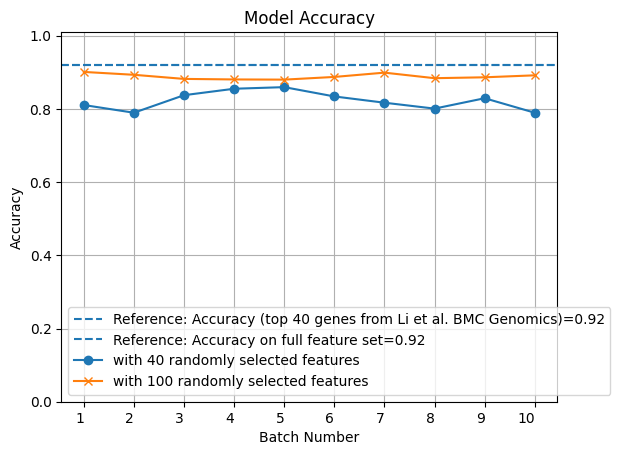

In [213]:
# plt.figure(figsize=(10, 6))

# Add a reference line
reference_value = top_40_gene_acc
reference_value_2 = round(0.9198868415638353,2)
plt.axhline(y=reference_value,  linestyle='--', label=f'Reference: Accuracy (top 40 genes from Li et al. BMC Genomics)={reference_value}')
plt.axhline(y=reference_value,  linestyle='--', label=f'Reference: Accuracy on full feature set={reference_value_2}')

plt.plot(batch_numbers, accuracy_random_40, marker='o', linestyle='-',  label="with 40 randomly selected features")
plt.plot(batch_numbers, accuracy_random_100, marker='x', linestyle='-',  label="with 100 randomly selected features")
# plt.plot(batch_numbers, accuracy_random_100, marker='*', label="with 100 randomly selected features")
# plt.plot(batch_numbers, rf_feature_selection_acc, marker='.', label="with 40 selected features sorted by Random Forest Feature Importance")

plt.title("Model Accuracy")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim([0, 1.01])
# plt.yticks((np.arange(0, 1, step=0.2)))
plt.grid(True)

plt.xticks(range(1, len(batch_numbers) + 1, 1), rotation=0, ha="right")

plt.legend()
plt.show()
# plt.savefig("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/TCGA/Results/model_accuracy_comapre_paper.png")

# GSE dataset

In [ ]:
!pip install GEOparse

In [ ]:
import GEOparse

# Download and parse the GSE dataset
gse = GEOparse.get_GEO("GSE4115")

# Extract phenotype data (labels)
pheno_data = gse.phenotype_data

# Inspect the phenotype data
print(pheno_data.head())

In [48]:
gse_class = pd.DataFrame(pheno_data['title'])

In [126]:
gse_class

,type
GSM93997,Smoker NOT diagnosed with cancer Sample
GSM94019,Smoker diagnosed with cancer Sample
GSM94020,Smoker diagnosed with cancer Sample
GSM94021,Smoker diagnosed with cancer Sample
GSM94022,Smoker diagnosed with cancer Sample
...,...
GSM98871,Smoker with suspect lung cancer Sample
GSM98872,Smoker with suspect lung cancer Sample
GSM98873,Smoker with suspect lung cancer Sample
GSM98874,Smoker with suspect lung cancer Sample


In [50]:
gse_class['title'] = gse_class['title'].str.replace(r'\d+', '', regex=True)

In [53]:
gse_class.rename(columns={'title': 'type'}, inplace=True)

In [3]:
file_path = "/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/GSE/GSE4115 series matrix.txt"
data = pd.read_csv(file_path, sep='\t', comment='!', header=None)

/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_58487/2795732209.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, sep='\t', comment='!', header=None)


In [14]:
# data.columns  = data.iloc[0]
data = data[1:]

In [16]:
data = data.reset_index(drop=True)

In [21]:
data.set_index('ID_REF', inplace=True)

In [24]:
data = data.T

In [144]:
data

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,90610_at,91580_at,91617_at,91682_at,91684_g_at,91703_at,91816_f_at,91826_at,91920_at,91952_at
0,,,,,,,,,,,,,,,,,,,,,
GSM93997,10.696879,4.236170,5.345251,7.919187,3.478706,7.142456,4.814028,4.112987,6.948436,3.270675,...,7.373103,3.232875,5.466897,5.952681,5.102564,5.49959,5.209175,7.569331,6.74773,5.968678
GSM94019,10.560653,4.173343,5.788414,8.180133,3.745022,7.667475,5.254227,4.303188,5.243215,3.417931,...,7.714989,3.491614,5.597842,6.394273,5.452602,5.669695,4.375323,8.200798,7.133049,6.531528
GSM94020,9.939516,4.559698,5.924607,8.207125,3.630689,7.807055,5.364942,4.498574,5.108143,3.463916,...,8.707332,3.655863,5.934463,6.547563,5.97831,6.043272,4.88996,8.535591,7.601025,6.540102
GSM94021,10.299866,4.359738,5.583276,8.213886,3.653105,7.509800,5.103016,4.137036,5.450892,3.526994,...,7.253566,3.333656,5.259695,6.299795,5.622406,5.984586,4.613341,7.427216,7.121853,6.43766
GSM94022,10.467122,4.245888,5.785865,8.184135,3.718874,7.588953,5.233377,4.029887,4.745138,3.156802,...,7.898104,3.511188,5.409353,6.27696,5.445675,5.611665,4.369342,8.122028,7.201006,6.31612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM98871,9.774809,4.300170,5.899963,8.335428,4.127119,7.794961,5.430378,4.280935,6.229742,3.861018,...,8.442677,3.513507,6.246132,6.467609,5.532636,5.665837,5.121925,9.070966,7.562132,6.439952
GSM98872,8.786862,4.420151,6.160850,8.806211,3.927962,6.851934,5.950592,4.524067,5.570813,3.934353,...,7.809692,3.66518,5.557841,7.188544,4.861121,4.950087,5.767322,7.359562,7.545254,6.362598
GSM98873,9.448081,4.390429,5.724537,8.754450,4.108549,6.753977,5.676697,4.542519,4.625017,3.400669,...,7.535618,3.407937,4.972289,6.576366,5.002253,5.153536,4.733896,7.135305,7.630269,6.29


In [143]:
data.iloc[0]

ID_REF
1007_s_at     10.696879
1053_at        4.236170
117_at         5.345251
121_at         7.919187
1255_g_at      3.478706
                ...    
91703_at        5.49959
91816_f_at     5.209175
91826_at       7.569331
91920_at        6.74773
91952_at       5.968678
Name: GSM93997, Length: 22215, dtype: object

In [150]:
gse_class.type.value_counts()

type
Smoker diagnosed with cancer Sample         97
Smoker NOT diagnosed with cancer Sample     90
Name: count, dtype: int64

In [148]:
gse_class = gse_class[gse_class['type'] != 'Smoker with suspect lung cancer Sample ']

In [151]:
gse_final = pd.merge(data, gse_class[['type']], left_index=True, right_index=True, how='inner')

In [149]:
gse_final.type.value_counts()

type
Smoker diagnosed with cancer Sample         97
Smoker NOT diagnosed with cancer Sample     90
Smoker with suspect lung cancer Sample       5
Name: count, dtype: int64

In [154]:
gse_final.dtypes

1007_s_at     object
1053_at       object
117_at        object
121_at        object
1255_g_at     object
               ...  
91816_f_at    object
91826_at      object
91920_at      object
91952_at      object
type          object
Length: 22216, dtype: object

In [153]:
temp = gse_final.apply(pd.to_numeric, errors='coerce')

In [155]:
gse_final.type

GSM93997    Smoker NOT diagnosed with cancer Sample 
GSM94019        Smoker diagnosed with cancer Sample 
GSM94020        Smoker diagnosed with cancer Sample 
GSM94021        Smoker diagnosed with cancer Sample 
GSM94022        Smoker diagnosed with cancer Sample 
                              ...                   
GSM98797    Smoker NOT diagnosed with cancer Sample 
GSM98798    Smoker NOT diagnosed with cancer Sample 
GSM98799    Smoker NOT diagnosed with cancer Sample 
GSM98800    Smoker NOT diagnosed with cancer Sample 
GSM98801    Smoker NOT diagnosed with cancer Sample 
Name: type, Length: 187, dtype: object

In [ ]:
# nan_count = temp.isnull().sum()
# len(nan_count[nan_count > 0].index), nan_count[nan_count > 0].index
# for i in range(1):
#     print(f"mean: {np.mean(cpm_gse.iloc[i]): .2f}, STD: {np.std(cpm_gse.iloc[i]): .2f}")

# CPM, Log2 on GSE

In [119]:
cpm_gse = temp.drop(columns=['type'])
library_size = cpm_gse.sum(axis=1)
print("Library size for each sample:\n", library_size)

Library size for each sample:
 0
GSM93997    127400.141293
GSM94019    126871.061360
GSM94020    126709.676696
GSM94021    126869.396066
GSM94022    126509.150671
                ...      
GSM98797    128270.595629
GSM98798    128141.412536
GSM98799    128620.669799
GSM98800    128434.154548
GSM98801    128292.631061
Length: 187, dtype: float64


In [120]:
cpm_gse = cpm_gse.div(library_size, axis=0) * 1e6
print("\nCPM Normalized Data:\n", cpm_gse)


CPM Normalized Data:
           1007_s_at    1053_at     117_at     121_at  1255_g_at    1294_at  \
0                                                                            
GSM93997  83.962850  33.250905  41.956398  62.159955  27.305354  56.063172   
GSM94019  83.239258  32.894365  45.624384  64.475956  29.518331  60.435177   
GSM94020  78.443228  35.985397  46.757337  64.771099  28.653605  61.613724   
GSM94021  81.184796  34.363985  44.008060  64.742848  28.794218  59.193156   
GSM94022  82.738062  33.561904  45.734755  64.692040  29.396087  59.987384   
...             ...        ...        ...        ...        ...        ...   
GSM98797  76.923803  33.890799  47.382746  65.381999  31.723607  55.697481   
GSM98798  75.346875  35.555773  45.701845  64.390433  31.242250  57.323724   
GSM98799  78.315188  33.872534  43.983452  63.120119  30.222172  59.839014   
GSM98800  81.036038  34.084859  44.126074  63.146941  28.916405  59.341372   
GSM98801  75.006810  33.981827  47.939760

In [124]:
tcga = np.log2(cpm_gse+1) # Log2 transformation with a pseudocount of 1
tcga = cpm_gse.apply(zscore, axis=0) # Z-score normalization (gene-wise)

In [127]:
gse_final = pd.merge(tcga, gse_class[['type']], left_index=True, right_index=True, how='inner')
gse_final.type.value_counts()

type
Smoker diagnosed with cancer Sample         97
Smoker NOT diagnosed with cancer Sample     90
Name: count, dtype: int64

In [129]:
temp = gse_final[gse_final['type'] != 'Smoker with suspect lung cancer Sample ']
temp.type.value_counts()

type
Smoker diagnosed with cancer Sample         97
Smoker NOT diagnosed with cancer Sample     90
Name: count, dtype: int64

# Check on Full feature set GSE

In [165]:
gse_final.shape

(187, 22216)

In [157]:
acc_gse_full_feature = check_model_stmfr(gse_final, "GSE")

Average for 5-fold cross-validation:  0.6192034139402561


In [162]:
random_features_model_accuracy(gse_final, batch_size=40, stop_at=10)

Batch 1 - Accuracy: 0.6842
Batch 2 - Accuracy: 0.7105
Batch 3 - Accuracy: 0.6842
Batch 4 - Accuracy: 0.6316
Batch 5 - Accuracy: 0.6579
Batch 6 - Accuracy: 0.6316
Batch 7 - Accuracy: 0.6842
Batch 8 - Accuracy: 0.6579
Batch 9 - Accuracy: 0.6316
Batch 10 - Accuracy: 0.6316


([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [0.6842105263157895,
  0.7105263157894737,
  0.6842105263157895,
  0.631578947368421,
  0.6578947368421053,
  0.631578947368421,
  0.6842105263157895,
  0.6578947368421053,
  0.631578947368421,
  0.631578947368421])

In [167]:
batch_numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

acc_gse_random_20=[0.7105263157894737,
  0.631578947368421,
  0.6578947368421053,
  0.6578947368421053,
  0.631578947368421,
  0.6842105263157895,
  0.631578947368421,
  0.6052631578947368,
  0.6052631578947368,
  0.5263157894736842]
acc_gse_random_100=[0.6842105263157895,
  0.6052631578947368,
  0.7105263157894737,
  0.6578947368421053,
  0.631578947368421,
  0.6578947368421053,
  0.7105263157894737,
  0.631578947368421,
  0.6052631578947368,
  0.7105263157894737]
acc_gse_random_40=[0.6842105263157895,
  0.7105263157894737,
  0.6842105263157895,
  0.631578947368421,
  0.6578947368421053,
  0.631578947368421,
  0.6842105263157895,
  0.6578947368421053,
  0.631578947368421,
  0.631578947368421]

In [ ]:
# Plot the accuracy values
plt.figure(figsize=(10, 6))

# Add a reference line
reference_value = round(acc_gse_full_feature,2)
plt.axhline(y=reference_value, color='g', linestyle='--', label=f'Reference: Accuracy (with all features: {gse_final.shape[1]-1})={reference_value}')

plt.plot(batch_numbers, acc_gse_random_20, marker='o', linestyle='-',  label="with 20 randomly selected features")
plt.plot(batch_numbers, acc_gse_random_40, marker='x', linestyle='-',  label="with 40 randomly selected features")
plt.plot(batch_numbers, acc_gse_random_100, marker='*', label="with 100 randomly selected features")

plt.title("Model Accuracy on GSE4115")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim([0, 1.01])
# plt.yticks((np.arange(0, 1, step=0.2)))
plt.grid(True)

plt.xticks(range(1, len(batch_numbers) + 1, 1), rotation=0, ha="right")

plt.legend()
plt.show()

# ALL/AML Dataset

In [12]:
y = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/ALL:AML/actual.csv")
print(y.shape)
y.head, y.columns

(72, 2)


(<bound method NDFrame.head of     patient cancer
 0         1    ALL
 1         2    ALL
 2         3    ALL
 3         4    ALL
 4         5    ALL
 ..      ...    ...
 67       68    ALL
 68       69    ALL
 69       70    ALL
 70       71    ALL
 71       72    ALL
 
 [72 rows x 2 columns]>,
 Index(['patient', 'cancer'], dtype='object'))

In [16]:
y.cancer.value_counts()

cancer
0    47
1    25
Name: count, dtype: int64

In [15]:
# Recode label to numeric
# y = y.replace({'ALL':0,'AML':1})
# labels = ['ALL', 'AML'] # for plotting convenience later on

label_encoder = LabelEncoder()
y['cancer'] = label_encoder.fit_transform(y.cancer)

    ALL --> 0
    AML --> 1

In [39]:
list(label_encoder.classes_)

[0, 1]

In [48]:
all_df_train = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/ALL:AML/data_set_ALL_AML_train.csv")
print(all_df_train.shape)

(7129, 78)


In [49]:
all_df_test = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/GE_Feature_Selection/Data/ALL:AML/data_set_ALL_AML_independent.csv")
print(all_df_test.shape)

(7129, 70)


In [50]:
all_df_train.head()

,Gene Description,Gene Accession Number,1,call,2,call.1,3,call.2,4,call.3,...,29,call.33,30,call.34,31,call.35,32,call.36,33,call.37
0,AFFX-BioB-5_at (endogenous control),AFFX-BioB-5_at,-214,A,-139,A,-76,A,-135,A,...,15,A,-318,A,-32,A,-124,A,-135,A
1,AFFX-BioB-M_at (endogenous control),AFFX-BioB-M_at,-153,A,-73,A,-49,A,-114,A,...,-114,A,-192,A,-49,A,-79,A,-186,A
2,AFFX-BioB-3_at (endogenous control),AFFX-BioB-3_at,-58,A,-1,A,-307,A,265,A,...,2,A,-95,A,49,A,-37,A,-70,A
3,AFFX-BioC-5_at (endogenous control),AFFX-BioC-5_at,88,A,283,A,309,A,12,A,...,193,A,312,A,230,P,330,A,337,A
4,AFFX-BioC-3_at (endogenous control),AFFX-BioC-3_at,-295,A,-264,A,-376,A,-419,A,...,-51,A,-139,A,-367,A,-188,A,-407,A


In [52]:
all_df_test.shape

(7129, 70)

In [53]:
train_to_keep = [col for col in all_df_train.columns if "call" not in col]
test_to_keep = [col for col in all_df_test.columns if "call" not in col]

X_train_tr = all_df_train[train_to_keep]
X_test_tr = all_df_test[test_to_keep]

In [55]:
train_columns_titles = ['Gene Description', 'Gene Accession Number', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', 
       '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38']

X_train_tr = X_train_tr.reindex(columns=train_columns_titles)

In [56]:
test_columns_titles = ['Gene Description', 'Gene Accession Number','39', '40', '41', '42', '43', '44', '45', '46',
       '47', '48', '49', '50', '51', '52', '53',  '54', '55', '56', '57', '58', '59',
       '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72']

X_test_tr = X_test_tr.reindex(columns=test_columns_titles)

In [57]:
X_train = X_train_tr.T
X_test = X_test_tr.T

print(X_train.shape) 
X_train.head()

(40, 7129)


,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
Gene Description,AFFX-BioB-5_at (endogenous control),AFFX-BioB-M_at (endogenous control),AFFX-BioB-3_at (endogenous control),AFFX-BioC-5_at (endogenous control),AFFX-BioC-3_at (endogenous control),AFFX-BioDn-5_at (endogenous control),AFFX-BioDn-3_at (endogenous control),AFFX-CreX-5_at (endogenous control),AFFX-CreX-3_at (endogenous control),AFFX-BioB-5_st (endogenous control),...,Transcription factor Stat5b (stat5b) mRNA,Breast epithelial antigen BA46 mRNA,GB DEF = Calcium/calmodulin-dependent protein ...,TUBULIN ALPHA-4 CHAIN,CYP4B1 Cytochrome P450; subfamily IVB; polypep...,PTGER3 Prostaglandin E receptor 3 (subtype EP3...,HMG2 High-mobility group (nonhistone chromosom...,RB1 Retinoblastoma 1 (including osteosarcoma),GB DEF = Glycophorin Sta (type A) exons 3 and ...,GB DEF = mRNA (clone 1A7)
Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41


In [58]:
# Clean up the column names for training and testing data
X_train.columns = X_train.iloc[1]
X_train = X_train.drop(["Gene Description", "Gene Accession Number"]).apply(pd.to_numeric)

# Clean up the column names for Testing data
X_test.columns = X_test.iloc[1]
X_test = X_test.drop(["Gene Description", "Gene Accession Number"]).apply(pd.to_numeric)

print(X_train.shape)
print(X_test.shape)
X_train.head()

(38, 7129)
(34, 7129)


Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [59]:
# Split into train and test (we first need to reset the index as the indexes of two dataframes need to be the same before you combine them).

# Subset the first 38 patient's cancer types
X_train = X_train.reset_index(drop=True)
y_train = y[y.patient <= 38].reset_index(drop=True)

# Subset the rest for testing
X_test = X_test.reset_index(drop=True)
y_test = y[y.patient > 38].reset_index(drop=True)

In [211]:
# Convert from integer to float
X_train = X_train.astype(float, 64)
X_test = X_test.astype(float, 64)

# # Apply the same scaling to both datasets
# scaler = StandardScaler()
# X_train_scl = scaler.fit_transform(X_train_fl)
# X_test_scl = scaler.transform(X_test_fl) # note that we transform rather than fit_transform

In [297]:
X_train.head() 

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-214.0,-153.0,-58.0,88.0,-295.0,-558.0,199.0,-176.0,252.0,206.0,...,185.0,511.0,-125.0,389.0,-37.0,793.0,329.0,36.0,191.0,-37.0
1,-139.0,-73.0,-1.0,283.0,-264.0,-400.0,-330.0,-168.0,101.0,74.0,...,169.0,837.0,-36.0,442.0,-17.0,782.0,295.0,11.0,76.0,-14.0
2,-76.0,-49.0,-307.0,309.0,-376.0,-650.0,33.0,-367.0,206.0,-215.0,...,315.0,1199.0,33.0,168.0,52.0,1138.0,777.0,41.0,228.0,-41.0
3,-135.0,-114.0,265.0,12.0,-419.0,-585.0,158.0,-253.0,49.0,31.0,...,240.0,835.0,218.0,174.0,-110.0,627.0,170.0,-50.0,126.0,-91.0
4,-106.0,-125.0,-76.0,168.0,-230.0,-284.0,4.0,-122.0,70.0,252.0,...,156.0,649.0,57.0,504.0,-26.0,250.0,314.0,14.0,56.0,-25.0


In [ ]:
# library_size = X_train.sum(axis=1)
# print("Library size for each sample:\n", library_size)

# cpm = X_train.div(library_size, axis=0) * 1e6
# print("\nCPM Normalized Data:\n", cpm)


log2 normalisation not possible as there are negative gene expressions

In [257]:
# cpm_log2 = np.log2(cpm+1) # Log2 transformation with a pseudocount of 1


X_train_zscore = X_train.apply(zscore, axis=0) # Z-score normalization (gene-wise)


In [263]:
X_test_zscore = X_test.apply(zscore, axis=0) 

In [259]:
X_train_zscore.head()

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-0.861496,-0.033101,-0.351701,-0.805738,-0.168417,-0.888716,1.120068,0.280962,1.863470,0.449110,...,0.074511,-0.815620,-1.758717,-0.021865,-0.405584,-0.159782,-0.033046,0.546068,-0.435820,-0.255875
1,-0.167723,1.037400,0.139139,0.876572,0.114600,0.293351,-1.322502,0.370212,0.023726,-0.182439,...,-0.116640,0.292993,-0.589006,0.092516,0.073055,-0.182892,-0.197260,-0.267043,-0.595744,0.499648
2,0.415047,1.358550,-2.495899,1.100880,-0.907912,-1.577008,0.353591,-1.849884,1.303018,-1.565148,...,1.627617,1.524030,0.317849,-0.498816,1.724361,0.565043,2.130709,0.708690,-0.384366,-0.387270
3,-0.130721,0.488768,2.429729,-1.461407,-1.300484,-1.090715,0.930757,-0.578070,-0.609828,-0.388171,...,0.731595,0.286192,2.749271,-0.485868,-2.152617,-0.508538,-0.800986,-2.251033,-0.526212,-2.029712
4,0.137537,0.341574,-0.506703,-0.115559,0.425006,1.161198,0.219688,0.883400,-0.353970,0.669195,...,-0.271951,-0.346330,0.633277,0.226322,-0.142332,-1.300593,-0.105493,-0.169469,-0.623557,0.138311


In [262]:
round(X_train_zscore.describe(),2)

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
count,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,...,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,...,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
std,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,...,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01
min,-3.29,-2.36,-2.50,-1.88,-2.41,-2.62,-2.01,-2.92,-2.21,-1.57,...,-1.78,-1.79,-2.46,-0.78,-2.20,-1.42,-1.42,-2.25,-0.70,-2.13
25%,-0.17,-0.73,-0.57,-0.86,-0.89,-0.81,-0.58,-0.42,-0.77,-0.76,...,-0.70,-0.60,-0.68,-0.48,-0.67,-0.58,-0.50,-0.36,-0.51,-0.44
50%,0.13,0.12,-0.23,0.16,0.12,0.10,0.05,0.17,0.01,-0.20,...,-0.05,-0.17,0.02,-0.29,0.05,-0.26,-0.13,0.03,-0.36,0.11
75%,0.49,0.75,0.55,0.84,0.80,0.71,0.57,0.63,0.65,0.62,...,0.63,0.74,0.63,0.11,0.70,0.51,0.26,0.36,-0.02,0.58
max,1.28,1.75,2.43,1.82,2.06,2.13,2.14,1.98,2.24,2.15,...,2.12,3.07,2.75,4.59,1.72,3.04,3.73,3.12,3.74,2.14


In [289]:
X_test_zscore.head()

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-2.844380,-0.257223,0.306000,1.238686,0.025884,-0.523312,-1.667952,-1.049687,0.856798,-0.936277,...,1.022196,1.556109,1.104685,-0.613631,-1.506468,1.001512,1.050378,0.909252,-0.394315,-0.784861
1,0.249432,-0.680824,2.043929,0.923680,0.010308,-0.960346,1.338615,-2.535584,1.481976,0.327970,...,-0.858006,-0.164410,-2.826066,-0.043162,-0.316934,-1.568936,-0.026902,-0.587509,-0.819890,0.229552
2,0.552747,1.304804,-0.071469,-0.536801,-0.044209,0.423596,-0.230796,0.761249,-0.777441,-0.630544,...,-0.412185,-0.672903,0.876658,-1.068353,1.117503,-1.114577,-0.529972,1.574480,-0.538290,0.291659
3,1.571885,0.157552,0.117265,0.742313,0.127130,0.648735,0.421656,0.352627,-0.645824,1.724427,...,2.340276,-0.617178,0.550906,0.808408,1.274941,0.539495,0.145869,0.133154,3.423164,-0.205196
4,2.348371,1.190079,-1.125237,0.513218,0.205011,-0.238577,-0.974355,-0.167436,-1.303907,-2.274892,...,1.642469,-1.689890,-0.534937,1.044037,-0.054537,1.412478,-1.317606,0.151633,2.521197,-1.012586


In [290]:
round(X_test_zscore.describe(),2)

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,...,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,...,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,...,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02
min,-2.84,-3.18,-3.24,-1.81,-2.40,-3.06,-2.79,-2.54,-2.27,-2.27,...,-2.22,-1.69,-2.83,-1.60,-2.99,-1.57,-1.58,-3.80,-0.89,-3.27
25%,-0.59,-0.40,-0.40,-0.54,-0.38,-0.33,-0.39,-0.43,-0.71,-0.74,...,-0.74,-0.66,-0.47,-0.51,-0.51,-0.65,-0.52,-0.33,-0.53,-0.65
50%,0.18,0.20,0.06,-0.20,0.15,0.25,-0.02,0.35,-0.14,0.08,...,-0.19,-0.07,0.27,-0.26,-0.06,-0.15,-0.14,0.02,-0.32,0.01
75%,0.62,0.61,0.36,0.73,0.44,0.67,0.61,0.67,0.78,0.47,...,0.39,0.41,0.71,0.40,0.89,0.51,0.50,0.52,-0.05,0.64
max,2.35,1.39,2.44,2.22,2.66,1.50,2.34,1.56,1.94,3.29,...,2.34,3.06,1.81,2.95,1.68,3.24,3.24,1.57,3.42,2.28


In [71]:
print("Simply predicting everything as acute lymphoblastic leukemia (ALL) results in an accuracy of ", round(1 - np.mean(y_test.iloc[:,1]), 3), ".", sep = '')

Simply predicting everything as acute lymphoblastic leukemia (ALL) results in an accuracy of 0.588.


In [282]:
# rf_model = RandomForestClassifier(bootstrap= False, max_features= 0.6, min_samples_leaf= 8, min_samples_split= 3, n_estimators= 60, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_zscore, y_train.iloc[:,1])

# Make predictions using the optimised parameters
rf_pred = rf_model.predict(X_test_zscore)

acc_full_set = round(accuracy_score(y_test.iloc[:,1], rf_pred), 3)
print('Random Forest accuracy:', acc_full_set)

Random Forest accuracy: 0.824


    Random Forest accuracy: 0.853 default model with random state = 42

    Random Forest accuracy: 0.912 with Best Parameters: {'bootstrap': False, 'max_features': 0.6, 'min_samples_leaf': 8, 'min_samples_split': 3, 'n_estimators': 60}


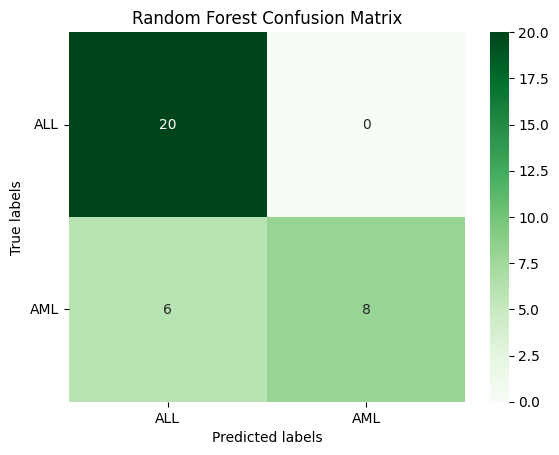

In [277]:
cm_rf = confusion_matrix(y_test.iloc[:,1], rf_pred)

ax = plt.subplot()
sns.heatmap(cm_rf, annot=True, ax = ax, fmt='g', cmap='Greens') 

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels') 
ax.set_title('Random Forest Confusion Matrix') 
ax.xaxis.set_ticklabels(labels) 
ax.yaxis.set_ticklabels(labels, rotation=360);

In [286]:
# Initialize list to store accuracy values
accuracy_values = []
batch_numbers = []

# Define batch size
batch_size = 1000
stop_at = 20

# Initialize batch counter
batch_number = 1

all_columns = X_train.columns

# Loop until all columns are exhausted
while len(all_columns) >= batch_size:
    # Randomly select 20 columns
    selected_columns = np.random.choice(all_columns, size=batch_size, replace=False)
    

    X_train_random = X_train_zscore[selected_columns]
    X_test_random = X_test_zscore[selected_columns]
    
    # Train a model (e.g., Random Forest)
    model = RandomForestClassifier(random_state=42)
    # model = RandomForestClassifier(bootstrap= False, max_features= 0.6, min_samples_leaf= 8, min_samples_split= 3, n_estimators= 60, random_state=42)
    model.fit(X_train_random, y_train.iloc[:,1])
    
    # Predict on the test set and calculate accuracy
    y_pred = model.predict(X_test_random)
    accuracy = accuracy_score(y_test.iloc[:,1], y_pred)

    # Store the accuracy value
    accuracy_values.append(accuracy)
    batch_numbers.append(batch_number)

    print(f"Batch {batch_number} - Accuracy: {accuracy:.4f}")
    
    # Remove the selected columns from the DataFrame
    # all_columns = all_columns.drop(selected_columns)
    
    # Increment the batch counter
    batch_number += 1

    if batch_number > stop_at:
        break

print("\n********************************")
print(f"Minimum: {min(accuracy_values)}")
print(f"Mean: {np.mean(accuracy_values)}")
print(f"STD: {np.std(accuracy_values)}")
print(f"Maximum: {max(accuracy_values)}")

Batch 1 - Accuracy: 0.7941
Batch 2 - Accuracy: 0.7353
Batch 3 - Accuracy: 0.7647
Batch 4 - Accuracy: 0.7353
Batch 5 - Accuracy: 0.7941
Batch 6 - Accuracy: 0.7941
Batch 7 - Accuracy: 0.7647
Batch 8 - Accuracy: 0.6765
Batch 9 - Accuracy: 0.7353
Batch 10 - Accuracy: 0.7059
Batch 11 - Accuracy: 0.7941
Batch 12 - Accuracy: 0.7059
Batch 13 - Accuracy: 0.7059
Batch 14 - Accuracy: 0.7941
Batch 15 - Accuracy: 0.7353
Batch 16 - Accuracy: 0.6765
Batch 17 - Accuracy: 0.7059
Batch 18 - Accuracy: 0.7647
Batch 19 - Accuracy: 0.7059
Batch 20 - Accuracy: 0.7059

********************************
Minimum: 0.6764705882352942
Mean: 0.7397058823529411
STD: 0.039760311278222826
Maximum: 0.7941176470588235


    default model, 100 genes Succesive removal
    (0.7261806130903066, 0.05853107692188916)

    default model, 100 random genes, no removal
    (0.7329411764705882, 0.06439497498072472)


    Opt model, 100 random genes, no removal
    (0.7450000000000001, 0.09594323220648952)

    Opt model, 100 genes Succesive removal
    (0.7373653686826842, 0.10975207248448383)



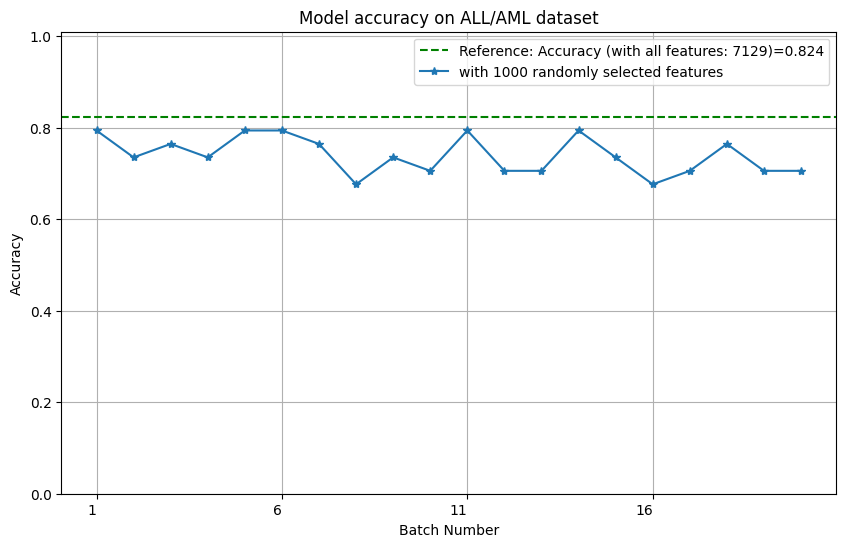

In [287]:
# Plot the accuracy values
plt.figure(figsize=(10, 6))

# Add a reference line

# Optimised model 
# acc_full_feature = 0.912

# default model 
acc_full_feature = acc_full_set

reference_value = round(acc_full_feature,3)
plt.axhline(y=reference_value, color='g', linestyle='--', label=f'Reference: Accuracy (with all features: {X_train.shape[1]})={reference_value}')

# plt.plot(batch_numbers, accuracy_random_20, marker='o', linestyle='-',  label="with 20 randomly selected features")
# plt.plot(batch_numbers, accuracy_random_40, marker='x', linestyle='-',  label="with 40 randomly selected features")
plt.plot(batch_numbers, accuracy_values, marker='*', label=f"with {batch_size} randomly selected features")

plt.title("Model accuracy on ALL/AML dataset")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim([0, 1.01])
# plt.yticks((np.arange(0, 1, step=0.2)))
plt.grid(True)

plt.xticks(range(1, len(batch_numbers) + 1, 5), rotation=0, ha="right")

plt.legend()
plt.show()

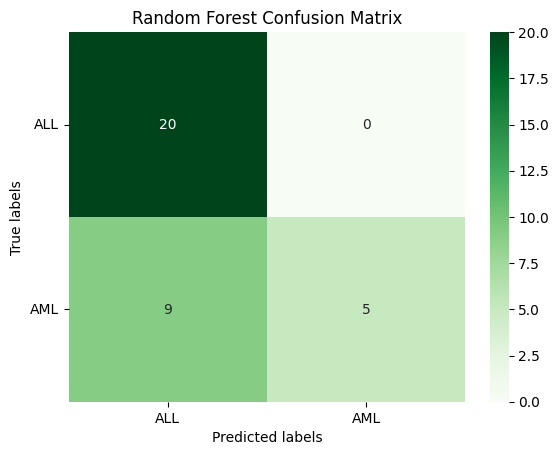

In [233]:
cm_rf = confusion_matrix(y_test.iloc[:,1], y_pred)

ax = plt.subplot()
sns.heatmap(cm_rf, annot=True, ax = ax, fmt='g', cmap='Greens') 

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels') 
ax.set_title('Random Forest Confusion Matrix') 
ax.xaxis.set_ticklabels(labels) 
ax.yaxis.set_ticklabels(labels, rotation=360);

In [293]:
X_train_zscore.head()

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-0.861496,-0.033101,-0.351701,-0.805738,-0.168417,-0.888716,1.120068,0.280962,1.863470,0.449110,...,0.074511,-0.815620,-1.758717,-0.021865,-0.405584,-0.159782,-0.033046,0.546068,-0.435820,-0.255875
1,-0.167723,1.037400,0.139139,0.876572,0.114600,0.293351,-1.322502,0.370212,0.023726,-0.182439,...,-0.116640,0.292993,-0.589006,0.092516,0.073055,-0.182892,-0.197260,-0.267043,-0.595744,0.499648
2,0.415047,1.358550,-2.495899,1.100880,-0.907912,-1.577008,0.353591,-1.849884,1.303018,-1.565148,...,1.627617,1.524030,0.317849,-0.498816,1.724361,0.565043,2.130709,0.708690,-0.384366,-0.387270
3,-0.130721,0.488768,2.429729,-1.461407,-1.300484,-1.090715,0.930757,-0.578070,-0.609828,-0.388171,...,0.731595,0.286192,2.749271,-0.485868,-2.152617,-0.508538,-0.800986,-2.251033,-0.526212,-2.029712
4,0.137537,0.341574,-0.506703,-0.115559,0.425006,1.161198,0.219688,0.883400,-0.353970,0.669195,...,-0.271951,-0.346330,0.633277,0.226322,-0.142332,-1.300593,-0.105493,-0.169469,-0.623557,0.138311


In [294]:
y_train.head()

,patient,cancer
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [307]:
X_train_zscore.head()


Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-0.861496,-0.033101,-0.351701,-0.805738,-0.168417,-0.888716,1.120068,0.280962,1.863470,0.449110,...,0.074511,-0.815620,-1.758717,-0.021865,-0.405584,-0.159782,-0.033046,0.546068,-0.435820,-0.255875
1,-0.167723,1.037400,0.139139,0.876572,0.114600,0.293351,-1.322502,0.370212,0.023726,-0.182439,...,-0.116640,0.292993,-0.589006,0.092516,0.073055,-0.182892,-0.197260,-0.267043,-0.595744,0.499648
2,0.415047,1.358550,-2.495899,1.100880,-0.907912,-1.577008,0.353591,-1.849884,1.303018,-1.565148,...,1.627617,1.524030,0.317849,-0.498816,1.724361,0.565043,2.130709,0.708690,-0.384366,-0.387270
3,-0.130721,0.488768,2.429729,-1.461407,-1.300484,-1.090715,0.930757,-0.578070,-0.609828,-0.388171,...,0.731595,0.286192,2.749271,-0.485868,-2.152617,-0.508538,-0.800986,-2.251033,-0.526212,-2.029712
4,0.137537,0.341574,-0.506703,-0.115559,0.425006,1.161198,0.219688,0.883400,-0.353970,0.669195,...,-0.271951,-0.346330,0.633277,0.226322,-0.142332,-1.300593,-0.105493,-0.169469,-0.623557,0.138311


In [316]:
# y_train.head()
y_train.iloc[0]

patient    1
cancer     0
Name: 0, dtype: int64

In [310]:
X_train_labelled = pd.merge(X_train_zscore, y_train[['cancer']], left_index=True, right_index=True, how='inner')

In [318]:
X_train_labelled.head()

,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,cancer
0,-0.861496,-0.033101,-0.351701,-0.805738,-0.168417,-0.888716,1.120068,0.280962,1.863470,0.449110,...,-0.815620,-1.758717,-0.021865,-0.405584,-0.159782,-0.033046,0.546068,-0.435820,-0.255875,0
1,-0.167723,1.037400,0.139139,0.876572,0.114600,0.293351,-1.322502,0.370212,0.023726,-0.182439,...,0.292993,-0.589006,0.092516,0.073055,-0.182892,-0.197260,-0.267043,-0.595744,0.499648,0
2,0.415047,1.358550,-2.495899,1.100880,-0.907912,-1.577008,0.353591,-1.849884,1.303018,-1.565148,...,1.524030,0.317849,-0.498816,1.724361,0.565043,2.130709,0.708690,-0.384366,-0.387270,0
3,-0.130721,0.488768,2.429729,-1.461407,-1.300484,-1.090715,0.930757,-0.578070,-0.609828,-0.388171,...,0.286192,2.749271,-0.485868,-2.152617,-0.508538,-0.800986,-2.251033,-0.526212,-2.029712,0
4,0.137537,0.341574,-0.506703,-0.115559,0.425006,1.161198,0.219688,0.883400,-0.353970,0.669195,...,-0.346330,0.633277,0.226322,-0.142332,-1.300593,-0.105493,-0.169469,-0.623557,0.138311,0


In [317]:
X_test_labelled = pd.merge(X_test_zscore, y_test[['cancer']], left_index=True, right_index=True, how='inner')

In [319]:
X_test_labelled.head()

,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,cancer
0,-2.844380,-0.257223,0.306000,1.238686,0.025884,-0.523312,-1.667952,-1.049687,0.856798,-0.936277,...,1.556109,1.104685,-0.613631,-1.506468,1.001512,1.050378,0.909252,-0.394315,-0.784861,0
1,0.249432,-0.680824,2.043929,0.923680,0.010308,-0.960346,1.338615,-2.535584,1.481976,0.327970,...,-0.164410,-2.826066,-0.043162,-0.316934,-1.568936,-0.026902,-0.587509,-0.819890,0.229552,0
2,0.552747,1.304804,-0.071469,-0.536801,-0.044209,0.423596,-0.230796,0.761249,-0.777441,-0.630544,...,-0.672903,0.876658,-1.068353,1.117503,-1.114577,-0.529972,1.574480,-0.538290,0.291659,0
3,1.571885,0.157552,0.117265,0.742313,0.127130,0.648735,0.421656,0.352627,-0.645824,1.724427,...,-0.617178,0.550906,0.808408,1.274941,0.539495,0.145869,0.133154,3.423164,-0.205196,0
4,2.348371,1.190079,-1.125237,0.513218,0.205011,-0.238577,-0.974355,-0.167436,-1.303907,-2.274892,...,-1.689890,-0.534937,1.044037,-0.054537,1.412478,-1.317606,0.151633,2.521197,-1.012586,0


In [322]:
X_train_zscore.shape, X_test_zscore.shape

((38, 7129), (34, 7129))

In [320]:
all_aml_df = pd.concat([X_train_labelled, X_test_labelled], ignore_index=True)

In [323]:
all_aml_df.shape

(72, 7130)

In [325]:
target = 'cancer'
all_aml_df[target]

0     0
1     0
2     0
3     0
4     0
     ..
67    0
68    0
69    0
70    0
71    0
Name: cancer, Length: 72, dtype: int64

In [448]:
acc_full_feature = check_model_stmfr(all_aml_df, "ALL/AML", 'cancer')

Average for 5-fold cross-validation: 0.9428571428571428 for ALL/AML


In [451]:
# Runtim: 2m 25s for Autoimmune disease dataset: number of samples : 1665, number of features: 12663, Target: binary classification

stop_at = 100
batches = [20, 40, 100]  # [50]
target = 'cancer'
remove_cols = False

for batch in batches:
    match batch:
        case 15:
            print("\n For batch size 15:")
            batch_numbers, accuracy_random_15 = random_features_model_accuracy(all_aml_df, target, remove_cols, batch_size=batch, stop_at=stop_at)
        case 20:
            print("\n For batch size 20:")
            batch_numbers, accuracy_random_20 = random_features_model_accuracy(all_aml_df, target, remove_cols, batch_size=batch, stop_at=stop_at)
        case 40:
            print("\n For batch size 40:")
            batch_numbers, accuracy_random_40 = random_features_model_accuracy(all_aml_df, target, remove_cols, batch_size=batch, stop_at=stop_at)
        case 50:
            print("\n For batch size 50:")
            batch_numbers, accuracy_random_50 = random_features_model_accuracy(all_aml_df, target, remove_cols, batch_size=batch, stop_at=stop_at)
        case 100:
            print("\n For batch size 100:")
            batch_numbers, accuracy_random_100 = random_features_model_accuracy(all_aml_df, target, remove_cols, batch_size=batch, stop_at=stop_at)    


 For batch size 20:
Batch 1 - Accuracy: 0.7333
Batch 2 - Accuracy: 0.8000
Batch 3 - Accuracy: 0.6667
Batch 4 - Accuracy: 0.7333
Batch 5 - Accuracy: 0.8667
Batch 6 - Accuracy: 0.8000
Batch 7 - Accuracy: 0.8667
Batch 8 - Accuracy: 0.6667
Batch 9 - Accuracy: 0.8667
Batch 10 - Accuracy: 0.8667
Batch 11 - Accuracy: 0.8000
Batch 12 - Accuracy: 0.9333
Batch 13 - Accuracy: 0.8000
Batch 14 - Accuracy: 0.6667
Batch 15 - Accuracy: 0.8000
Batch 16 - Accuracy: 0.7333
Batch 17 - Accuracy: 0.8000
Batch 18 - Accuracy: 0.6667
Batch 19 - Accuracy: 0.9333
Batch 20 - Accuracy: 0.7333
Batch 21 - Accuracy: 0.6667
Batch 22 - Accuracy: 0.8667
Batch 23 - Accuracy: 0.9333
Batch 24 - Accuracy: 0.8000
Batch 25 - Accuracy: 0.8000
Batch 26 - Accuracy: 0.8000
Batch 27 - Accuracy: 0.8667
Batch 28 - Accuracy: 0.8667
Batch 29 - Accuracy: 0.9333
Batch 30 - Accuracy: 0.8000
Batch 31 - Accuracy: 0.7333
Batch 32 - Accuracy: 0.7333
Batch 33 - Accuracy: 0.8667
Batch 34 - Accuracy: 0.8000
Batch 35 - Accuracy: 0.8667
Batch 36

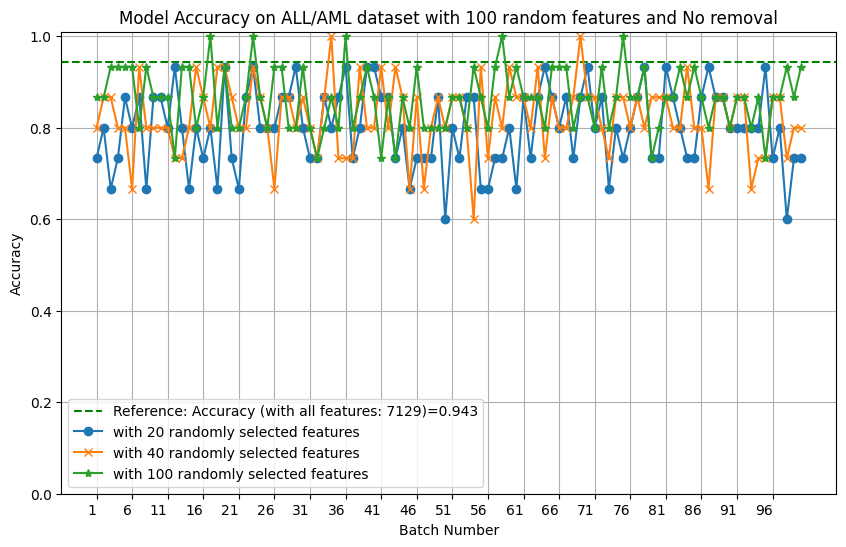

In [453]:
# Plot the accuracy values
plt.figure(figsize=(10, 6))

# Add a reference line
reference_value = round(acc_full_feature,3)
plt.axhline(y=reference_value, color='g', linestyle='--', label=f'Reference: Accuracy (with all features: {all_aml_df.shape[1]-1})={reference_value}')

plt.plot(batch_numbers, accuracy_random_20, marker='o', linestyle='-',  label="with 20 randomly selected features")
plt.plot(batch_numbers, accuracy_random_40, marker='x', linestyle='-',  label="with 40 randomly selected features")
plt.plot(batch_numbers, accuracy_random_100, marker='*', label="with 100 randomly selected features")

plt.title("Model Accuracy on ALL/AML dataset with 100 random features and No removal")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim([0, 1.01])
# plt.yticks((np.arange(0, 1, step=0.2)))
plt.grid(True)

# plt.annotate(f'Mean:{round(np.mean(accuracy_random_50),2)}',xy=(0.4,0.5))
# plt.annotate(f'STD:{round(np.std(accuracy_random_50),3)}',xy=(0.4,0.45))
plt.xticks(range(1, len(batch_numbers) + 1, 5), rotation=0, ha="right")

plt.legend()
plt.show()

In [369]:
all_aml_df.columns

Index(['AFFX-BioB-5_at', 'AFFX-BioB-M_at', 'AFFX-BioB-3_at', 'AFFX-BioC-5_at',
       'AFFX-BioC-3_at', 'AFFX-BioDn-5_at', 'AFFX-BioDn-3_at',
       'AFFX-CreX-5_at', 'AFFX-CreX-3_at', 'AFFX-BioB-5_st',
       ...
       'U58516_at', 'U73738_at', 'X06956_at', 'X16699_at', 'X83863_at',
       'Z17240_at', 'L49218_f_at', 'M71243_f_at', 'Z78285_f_at', 'cancer'],
      dtype='object', length=7130)

# Comparison with Golub et. al., 1999

In [413]:
freq_50_genes = ['U22376', 'X59417', 'U05259', 'M92287', 'M31211','X74262', 'D26156', 'S50223', 'M31523', 'L47738','U32944','Z15115', 'X15949','X63469', 'M91432', 'U29175', 'Z69881','U20998', 'D38073','U26266','M31303','Y08612','U35451','M29696','M13792',
                 'M55150','X95735','U50136','M16038','U82759','M23197','M84526','Y12670','M27891','X17042','Y00787','M96326','U46751','M80254','L08246','M62762','M28130','M63138','M57710','M69043','M81695','X85116','M19045','M83652','X04085']

In [414]:
len(freq_50_genes)

50

In [415]:
all_cols = all_aml_df.columns

In [ ]:
# for col in freq_50_genes:
#     if col in all_cols:
#         # print(f"'{col}' exists")
#         pass
#     else:
#         print(f"'{col}' does not exist")

In [417]:
cols_paper = []
count=0
for substring in freq_50_genes:

    # Find columns that contain the substring
    matching_columns = [col for col in all_aml_df.columns if substring in col]
    cols_paper.append(matching_columns)
    print(matching_columns)

['U22376_cds2_s_at']
['X59417_at']
['U05259_rna1_at']
['M92287_at']
['M31211_s_at']
['X74262_at']
['D26156_s_at']
['S50223_at']
['M31523_at']
['L47738_at']
['U32944_at']
['Z15115_at']
['X15949_at']
['X63469_at']
['M91432_at']
['U29175_at']
['Z69881_at']
['U20998_at']
['D38073_at']
['U26266_s_at']
['M31303_rna1_at']
['Y08612_at']
['U35451_at']
['M29696_at']
['M13792_at']
['M55150_at']
['X95735_at']
['U50136_rna1_at']
['M16038_at']
['U82759_at']
['M23197_at']
['M84526_at']
['Y12670_at']
['M27891_at']
['X17042_at']
['Y00787_s_at']
['M96326_rna1_at']
['U46751_at']
['M80254_at']
['L08246_at']
['M62762_at']
['M28130_rna1_s_at']
['M63138_at']
['M57710_at']
['M69043_at']
['M81695_s_at']
['X85116_rna1_s_at']
['M19045_f_at']
['M83652_s_at']
['X04085_rna1_at']


In [419]:
flattened_list = [item for sublist in cols_paper for item in sublist]
print(flattened_list)

['U22376_cds2_s_at', 'X59417_at', 'U05259_rna1_at', 'M92287_at', 'M31211_s_at', 'X74262_at', 'D26156_s_at', 'S50223_at', 'M31523_at', 'L47738_at', 'U32944_at', 'Z15115_at', 'X15949_at', 'X63469_at', 'M91432_at', 'U29175_at', 'Z69881_at', 'U20998_at', 'D38073_at', 'U26266_s_at', 'M31303_rna1_at', 'Y08612_at', 'U35451_at', 'M29696_at', 'M13792_at', 'M55150_at', 'X95735_at', 'U50136_rna1_at', 'M16038_at', 'U82759_at', 'M23197_at', 'M84526_at', 'Y12670_at', 'M27891_at', 'X17042_at', 'Y00787_s_at', 'M96326_rna1_at', 'U46751_at', 'M80254_at', 'L08246_at', 'M62762_at', 'M28130_rna1_s_at', 'M63138_at', 'M57710_at', 'M69043_at', 'M81695_s_at', 'X85116_rna1_s_at', 'M19045_f_at', 'M83652_s_at', 'X04085_rna1_at']


In [422]:
df_50_genes = all_aml_df[flattened_list]

In [423]:
df_50_genes['cancer'] = all_aml_df['cancer']

/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_69066/2370335949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_50_genes['cancer'] = all_aml_df['cancer']


In [430]:
df_50_genes.cancer.value_counts()

cancer
0    47
1    25
Name: count, dtype: int64

In [429]:
# paper_50_gen_acc = check_model_stmfr(df_50_genes, "ALL/AML", 'cancer')
check_model_stmfr(df_50_genes, "ALL/AML", 'cancer')

Average for 5-fold cross-validation: 0.9857142857142858 for ALL/AML


0.9857142857142858